# FluxTransformer: A Neural Surrogate for Metabolic Flux Prediction

This notebook implements *FluxTransformer*, a neural surrogate model designed to predict flux distributions in the *E. coli core* metabolic network. The model uses a Transformer-based architecture with multi-head attention and feedforward layers to approximate the results of Flux Balance Analysis (FBA) from extracellular metabolite uptake rates.

The notebook includes:

* Data preprocessing and preparation

* Model architecture implemented in PyTorch

* Training and evaluation on simulated flux datasets

* Systematic testing of multiple Transformer model configurations to assess performance

In [1]:
import os
import random
import time
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#DATA_PATH = "./data/2025-07-15_full_training_data_98066_samples.csv" # carbons log-uniform, others uniform
DATA_PATH = "./data/2025-07-24_full_training_data_49014_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_29446_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_19637_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_9844_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-15_full_training_data_99518_easy_samples.csv" #log-uniform samples

In [3]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [4]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

Training on device: cuda
PyTorch version: 2.5.1+cu121


In [5]:
def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active CUDA device.
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'Allocated memory: {allocated:.2f} MB')
        print(f'Reserved memory: {reserved:.2f} MB')
    else:
        print("CUDA is not available.")

In [ ]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        # c projection to match d_model
        #self.Wc_proj = nn.Linear(1, d_model, bias=False)
        #self.Wc_out = nn.Linear(d_model, 1, bias=False)

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x)
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True)
        # attn_out: (B, S, d_model)
        # attn_weights: (B, S, S) averaged over heads

        x_out = attn_out + x
        #c_proj = self.Wc_proj(c)            # (B, S, d_model)
        # Apply attention weights: (B, S, S) @ (B, S, d_model) -> (B, S, d_model)
        c_att = torch.bmm(attn_weights, c)
        #c_att = torch.bmm(attn_weights, c_proj)
        c_out = c_att + c
        #c_out = self.Wc_out(c_att) + c      # (B, S, 1)

        return x_out, c_out

In [ ]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.LeakyReLU(0.01)
        #self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [8]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c

In [9]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=115,
        d_model=8,
        n_heads=2,
        n_layers=2,
        d_ff=128,
        dropout=0.1
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        
        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c):
        batch_size = c.size(0)
        
        # Create token indices once
        y = torch.arange(self.vocab_size, device=c.device)
        y = y.unsqueeze(0).expand(batch_size, -1)  # (batch, seq)
        
        # Embed tokens once
        x = self.input_embedding(y)  # (batch, seq, d_model)
        
        for layer in self.layers:
            x, c = layer(x, c)
        
        return c

In [10]:
def load_data(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, inputs, outputs

In [11]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Optional: standardize inputs (only input features, i.e., first 20 columns)
    # scaler = StandardScaler()
    # X_train[:, :20] = scaler.fit_transform(X_train[:, :20])
    # X_test[:, :20] = scaler.transform(X_test[:, :20])

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [12]:
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    """
    Create PyTorch DataLoaders for training and testing.

    Parameters:
        X_train, y_train (Tensor): Training data and labels.
        X_test, y_test (Tensor): Test data and labels.
        batch_size (int): Batch size for loading.

    Returns:
        train_loader, test_loader (DataLoader): PyTorch DataLoaders.
    """
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [13]:
# Load and preprocess data

X, y, input_cols, output_cols = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)


Loaded data with 49014 samples from ./data/2025-07-24_full_training_data_49014_samples.csv
Number of input features: 20
Number of output targets: 95
Training samples: 29408
Test samples: 19606


In [14]:
X_train.size(), y_train.size()

(torch.Size([29408, 115]), torch.Size([29408, 115]))

In [15]:
def train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128, num_epochs=1000, learning_rate=0.001):
    start_time = time.time()

    model = FluxTransformer(
        vocab_size=115,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    #optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    #criterion = nn.MSELoss()
    criterion = nn.HuberLoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            torch.cuda.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                torch.cuda.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        # Additional memory cleanup after epoch
        torch.cuda.empty_cache()
        gc.collect()

    print('Training Completed.')
    end_time = time.time()
    elapsed_time = end_time - start_time
    mins, secs = divmod(elapsed_time, 60)
    print(f"Training took {int(mins)} min {secs:.1f} sec.")
    
    return train_losses, test_losses, model

### Plotting Functions

In [16]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    plt.show()

In [17]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [31]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    pred = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,0].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [33]:
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
    device: torch.device,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 95 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"{flux_name} index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

### Exploring Model Variants

The following cells test multiple Transformer configurations with varying model sizes, attention heads, and feedforward dimensions. Each variant is trained, evaluated, and visualized to assess its performance and scalability.

Allocated memory: 43.00 MB
Reserved memory: 48.00 MB
Epoch 100/1000 | Train Loss: 1.086732 | Test Loss: 0.904917
Epoch 200/1000 | Train Loss: 0.901881 | Test Loss: 0.740043
Epoch 300/1000 | Train Loss: 0.842948 | Test Loss: 0.679537
Epoch 400/1000 | Train Loss: 0.813503 | Test Loss: 0.653707
Epoch 500/1000 | Train Loss: 0.793755 | Test Loss: 0.642112
Epoch 600/1000 | Train Loss: 0.774043 | Test Loss: 0.611428
Epoch 700/1000 | Train Loss: 0.759718 | Test Loss: 0.604950
Epoch 800/1000 | Train Loss: 0.749075 | Test Loss: 0.595527
Epoch 900/1000 | Train Loss: 0.742705 | Test Loss: 0.585883
Epoch 1000/1000 | Train Loss: 0.738904 | Test Loss: 0.587626
Training Completed.
Training took 75 min 43.9 sec.


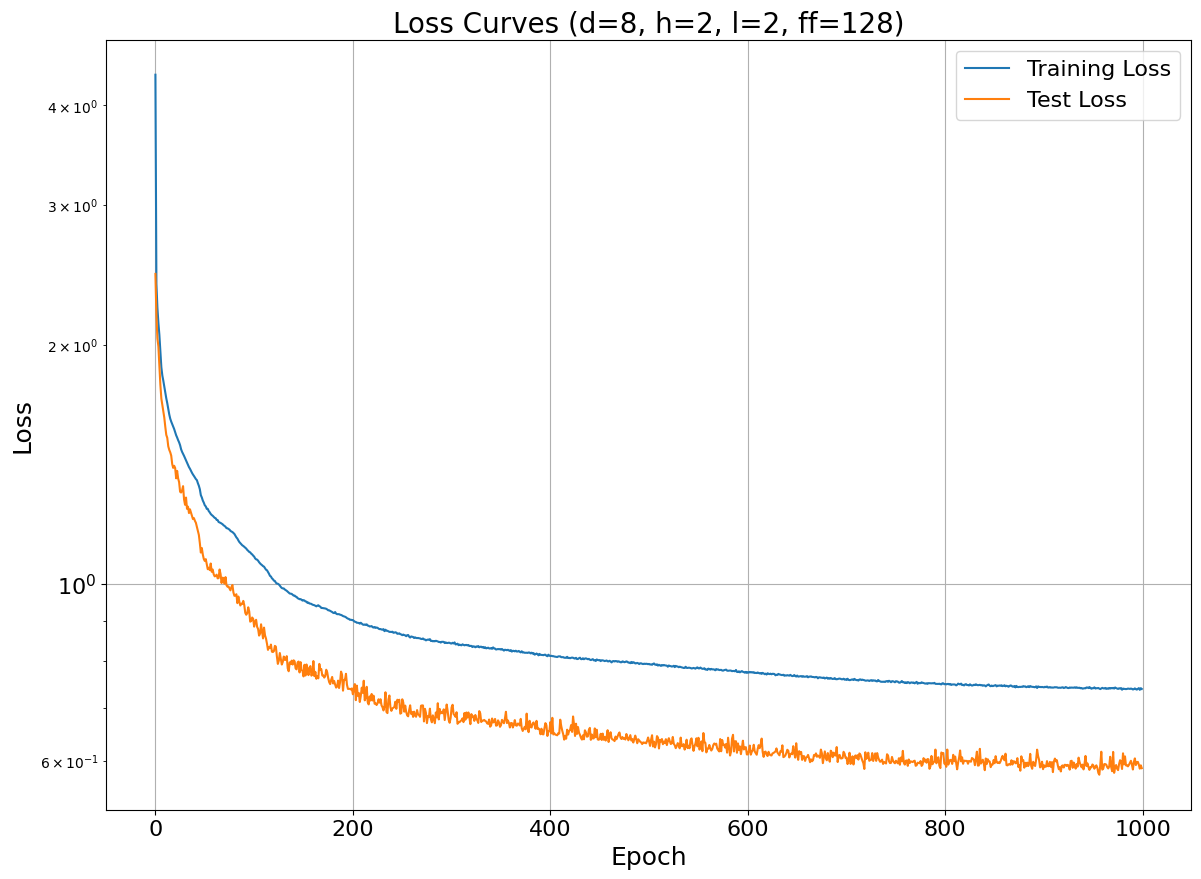

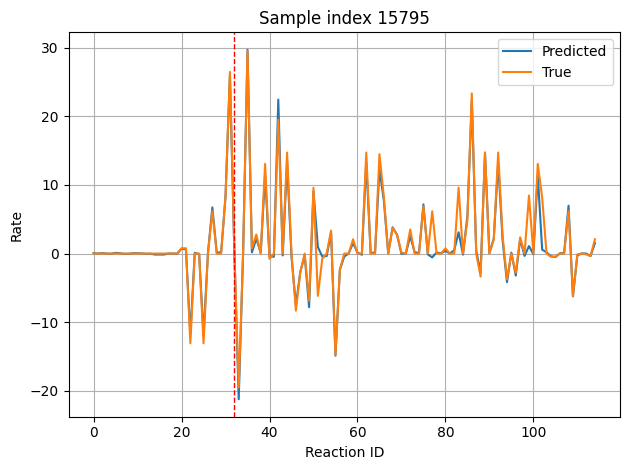

y_pred_outputs.shape: (19606, 95) min/max: -71.5519 108.0949
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: 0.047428995 to 1.8672602


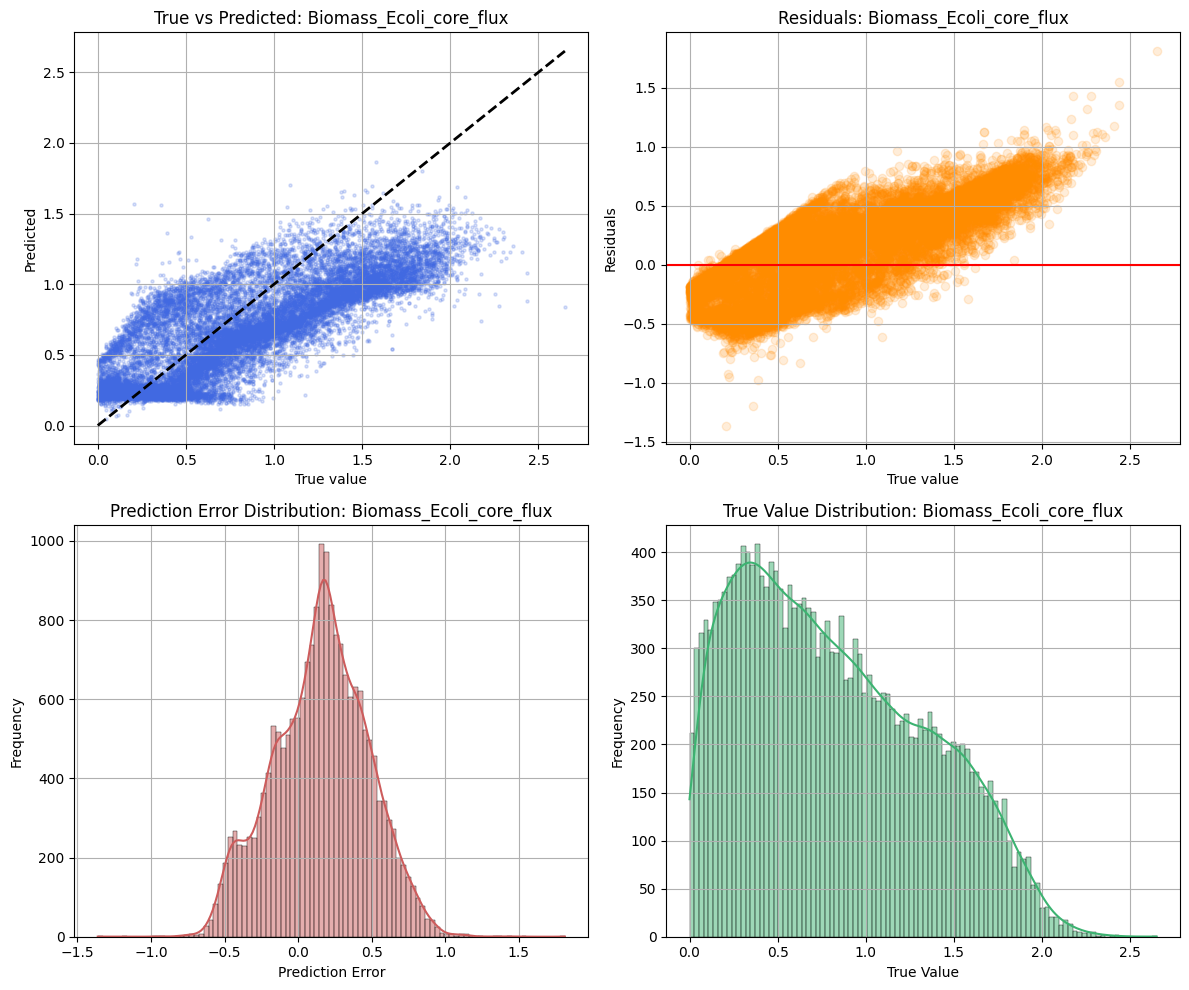

Number of parameters:
6478


In [20]:
print_gpu_memory()

train_losses, test_losses, model_822 = train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_loss_curves(train_losses, test_losses, d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_822)

plot_flux(model_822, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.737972 | Test Loss: 0.589912
Epoch 200/1000 | Train Loss: 0.647207 | Test Loss: 0.492178
Epoch 300/1000 | Train Loss: 0.607756 | Test Loss: 0.459106
Epoch 400/1000 | Train Loss: 0.577493 | Test Loss: 0.430303
Epoch 500/1000 | Train Loss: 0.560423 | Test Loss: 0.410682
Epoch 600/1000 | Train Loss: 0.544875 | Test Loss: 0.395076
Epoch 700/1000 | Train Loss: 0.536132 | Test Loss: 0.403196
Epoch 800/1000 | Train Loss: 0.530531 | Test Loss: 0.384281
Epoch 900/1000 | Train Loss: 0.526904 | Test Loss: 0.383092
Epoch 1000/1000 | Train Loss: 0.522802 | Test Loss: 0.390994
Training Completed.
Training took 76 min 50.3 sec.


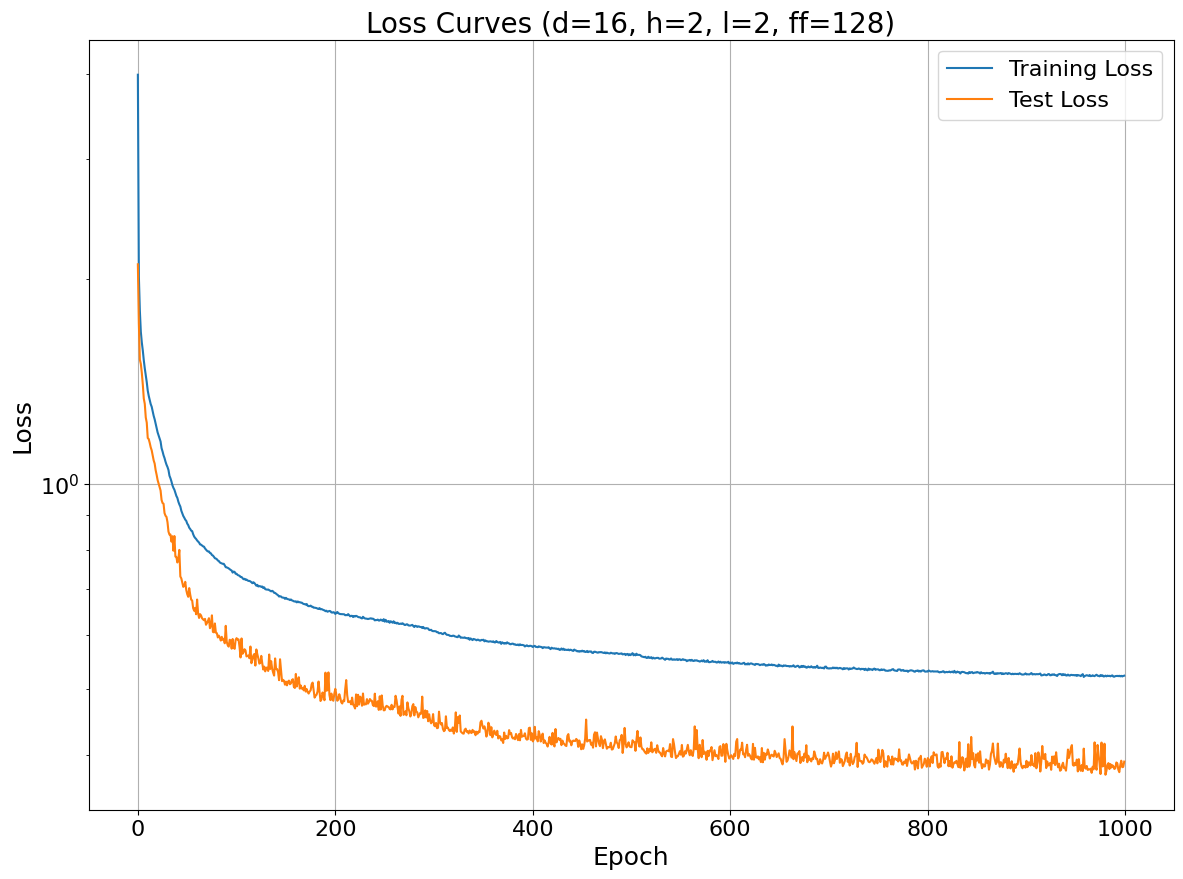

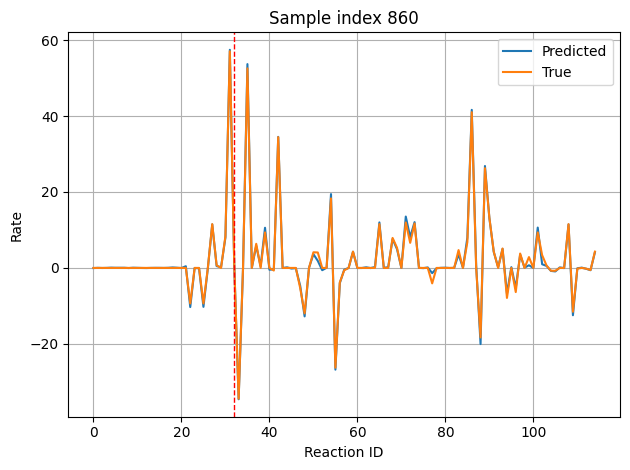

y_pred_outputs.shape: (19606, 95) min/max: -73.23687 113.320114
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: 0.17701632 to 2.7319734


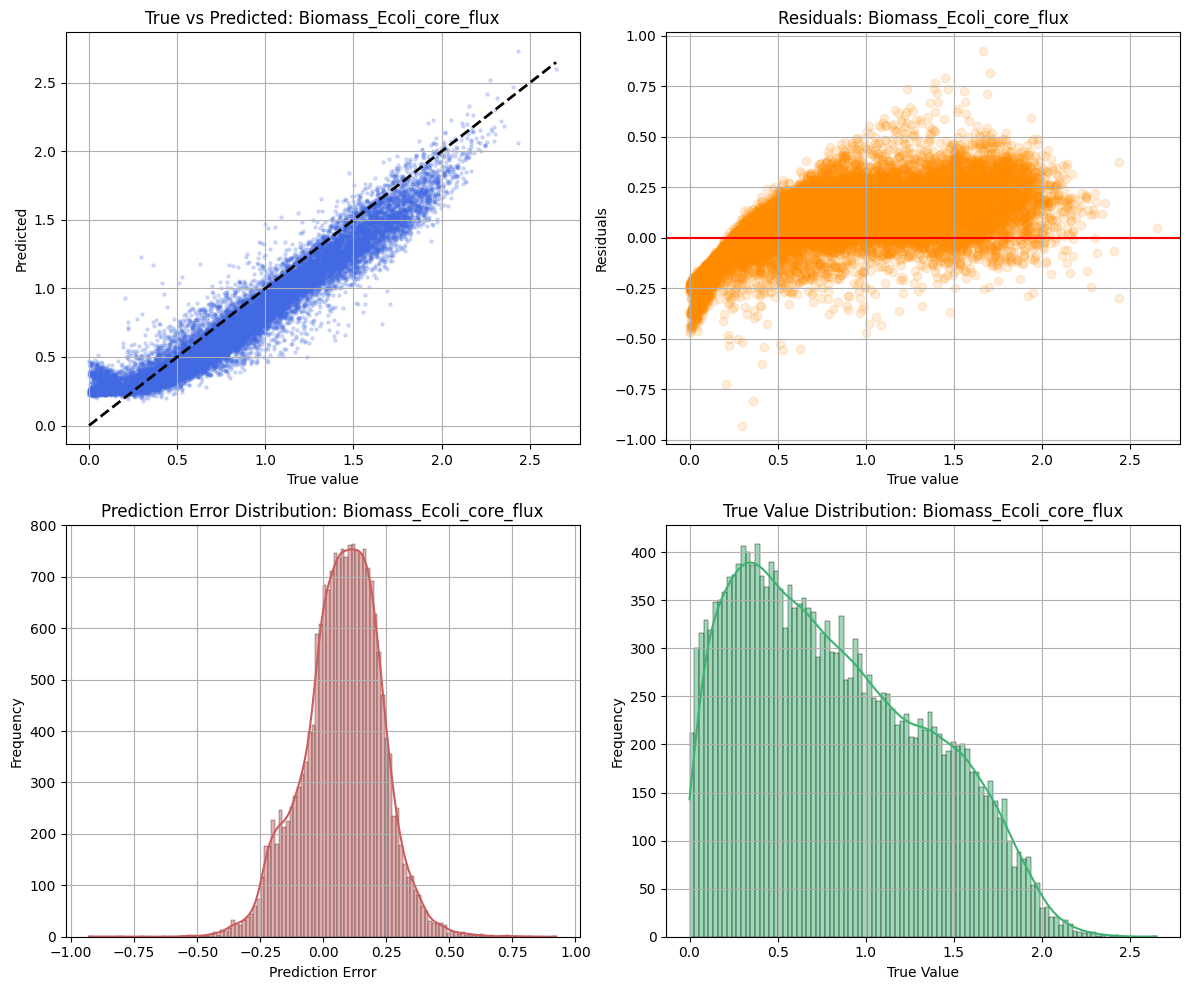

Number of parameters:
13206


In [21]:
train_losses_1622, test_losses_1622, model_1622 = train_model(d_model=16, n_heads=2, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_1622, test_losses_1622, d_model=16, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_1622)

plot_flux(model_1622, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_1622.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.693033 | Test Loss: 0.524258
Epoch 200/1000 | Train Loss: 0.619412 | Test Loss: 0.486395
Epoch 300/1000 | Train Loss: 0.587423 | Test Loss: 0.450050
Epoch 400/1000 | Train Loss: 0.570247 | Test Loss: 0.422330
Epoch 500/1000 | Train Loss: 0.552575 | Test Loss: 0.406057
Epoch 600/1000 | Train Loss: 0.537212 | Test Loss: 0.405776
Epoch 700/1000 | Train Loss: 0.524250 | Test Loss: 0.385952
Epoch 800/1000 | Train Loss: 0.514498 | Test Loss: 0.372059
Epoch 900/1000 | Train Loss: 0.506478 | Test Loss: 0.360175
Epoch 1000/1000 | Train Loss: 0.502729 | Test Loss: 0.371470
Training Completed.
Training took 98 min 49.4 sec.


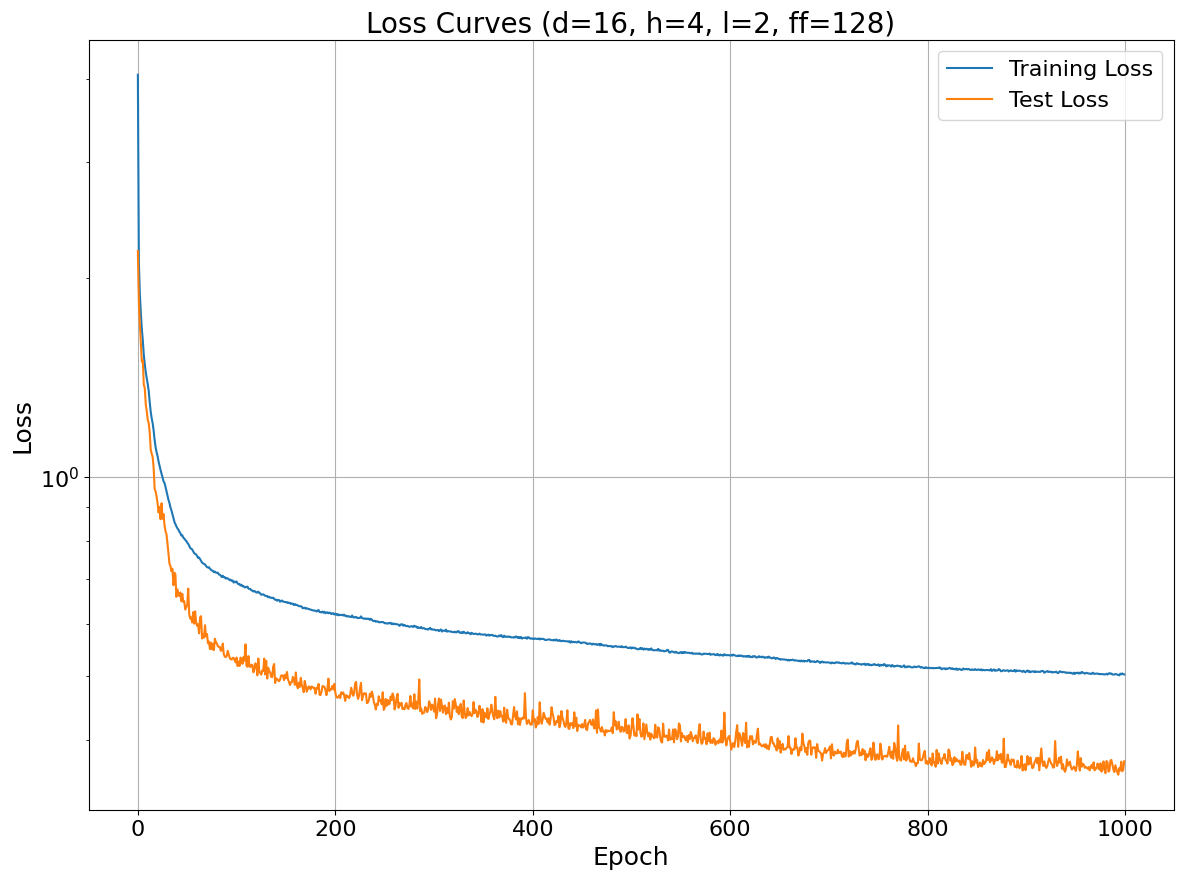

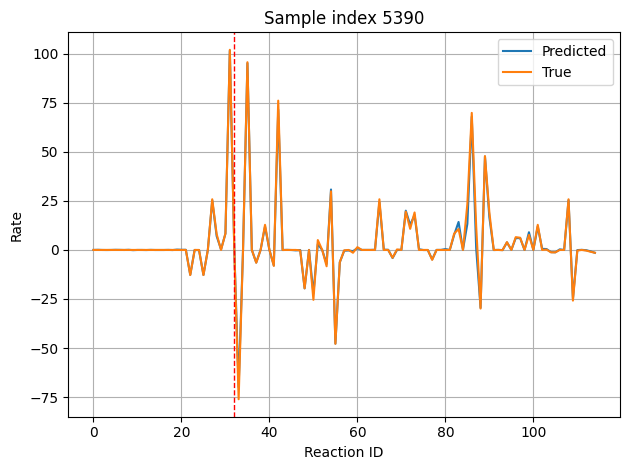

y_pred_outputs.shape: (19606, 95) min/max: -69.90861 105.646576
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.2459032 to 2.961333


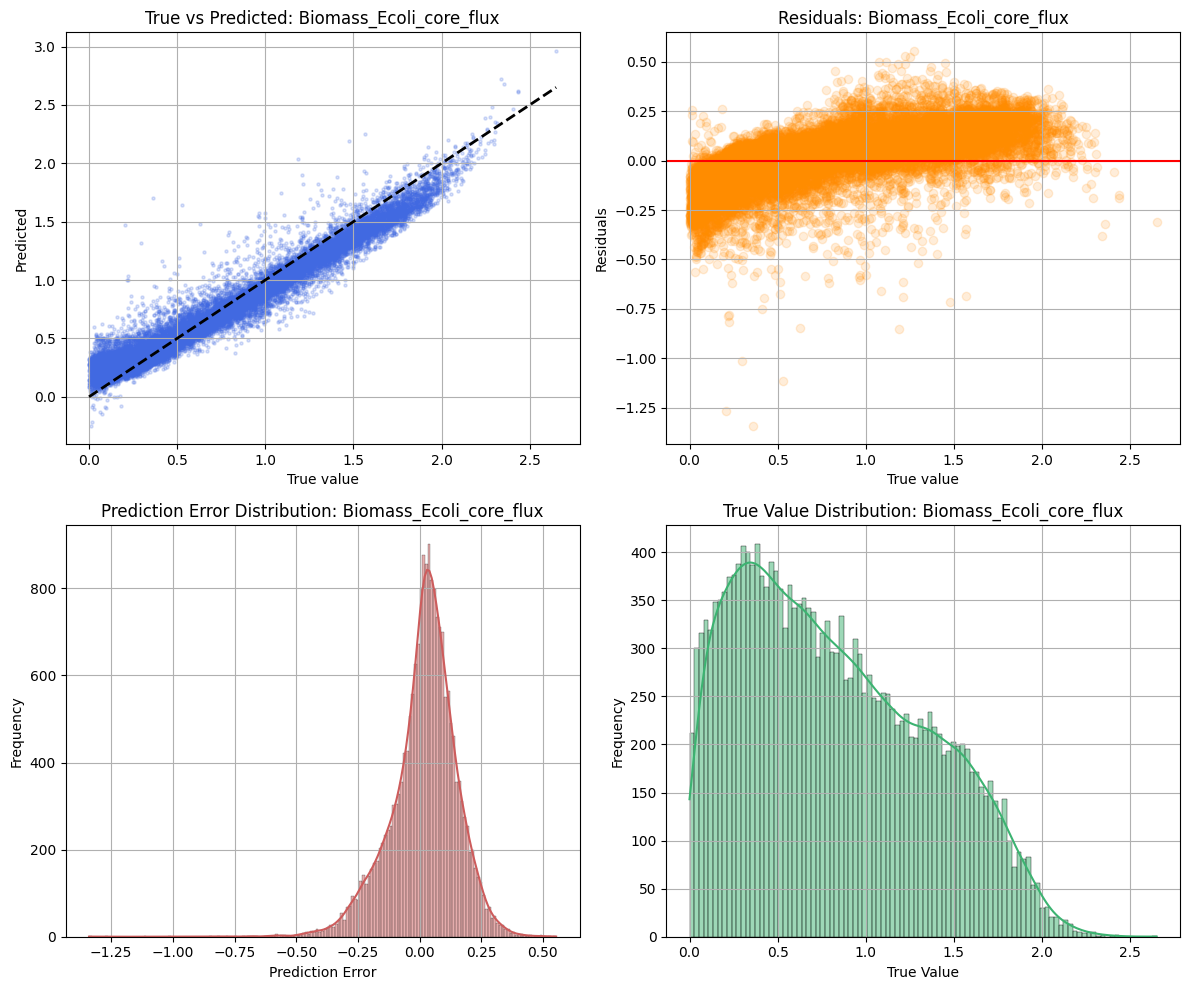

Number of parameters:
13206


In [22]:
train_losses_1642, test_losses_1642, model_1642 = train_model(d_model=16, n_heads=4, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_1642, test_losses_1642, d_model=16, n_heads=4, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_1642)

plot_flux(model_1642, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_1642.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.552894 | Test Loss: 0.414298
Epoch 200/1000 | Train Loss: 0.478720 | Test Loss: 0.347632
Epoch 300/1000 | Train Loss: 0.451357 | Test Loss: 0.325692
Epoch 400/1000 | Train Loss: 0.433820 | Test Loss: 0.320068
Epoch 500/1000 | Train Loss: 0.422379 | Test Loss: 0.323200
Epoch 600/1000 | Train Loss: 0.415102 | Test Loss: 0.309354
Epoch 700/1000 | Train Loss: 0.407056 | Test Loss: 0.308713
Epoch 800/1000 | Train Loss: 0.401764 | Test Loss: 0.288609
Epoch 900/1000 | Train Loss: 0.398481 | Test Loss: 0.296565
Epoch 1000/1000 | Train Loss: 0.393418 | Test Loss: 0.285661
Training Completed.
Training took 78 min 41.3 sec.


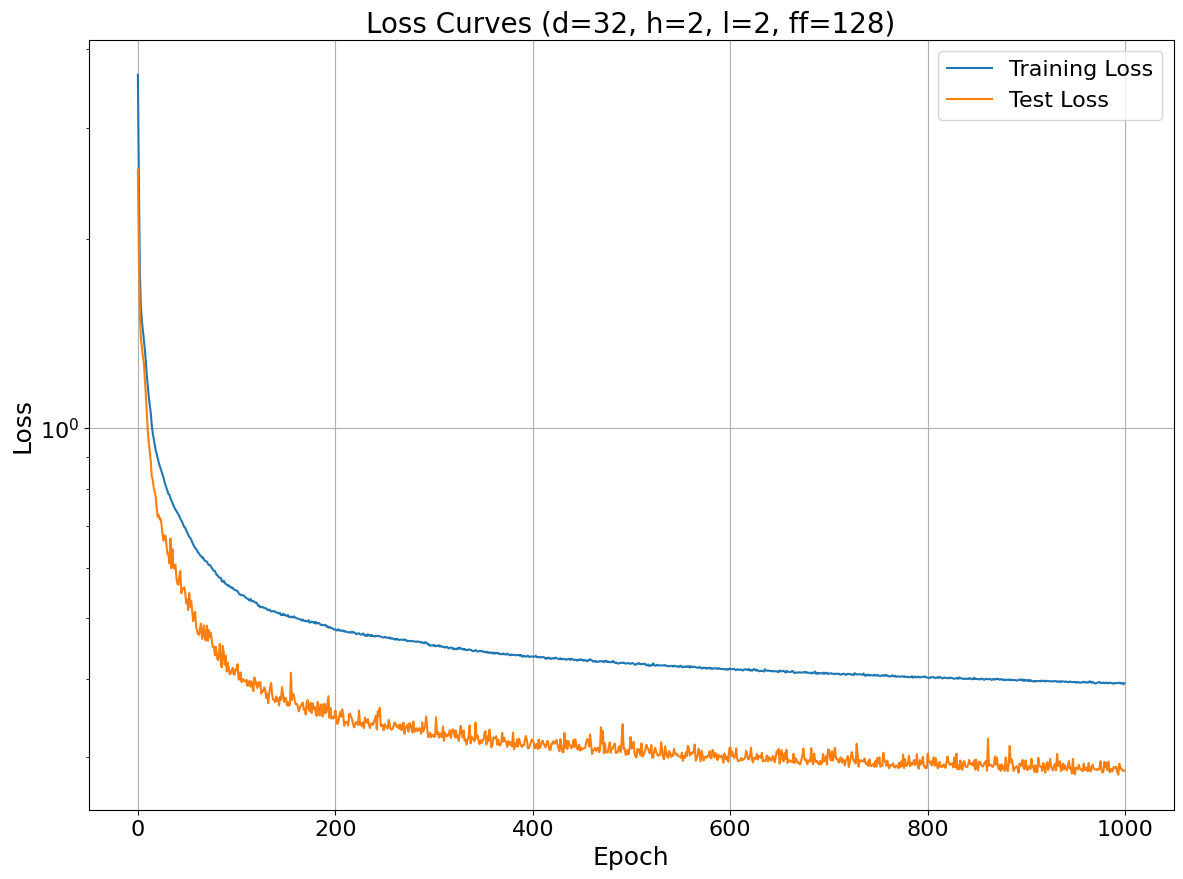

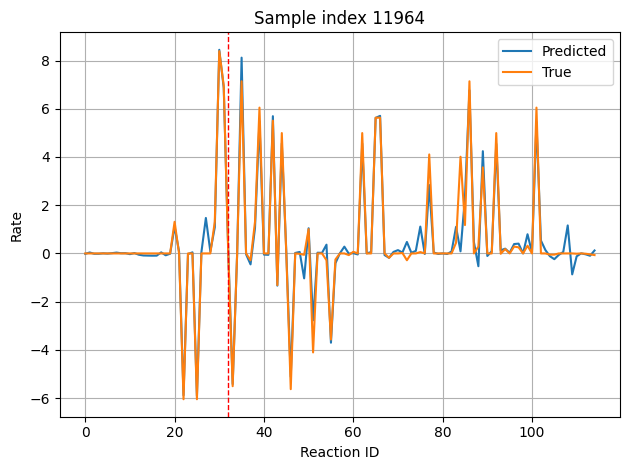

y_pred_outputs.shape: (19606, 95) min/max: -73.470276 107.59019
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.12383807 to 2.1778655


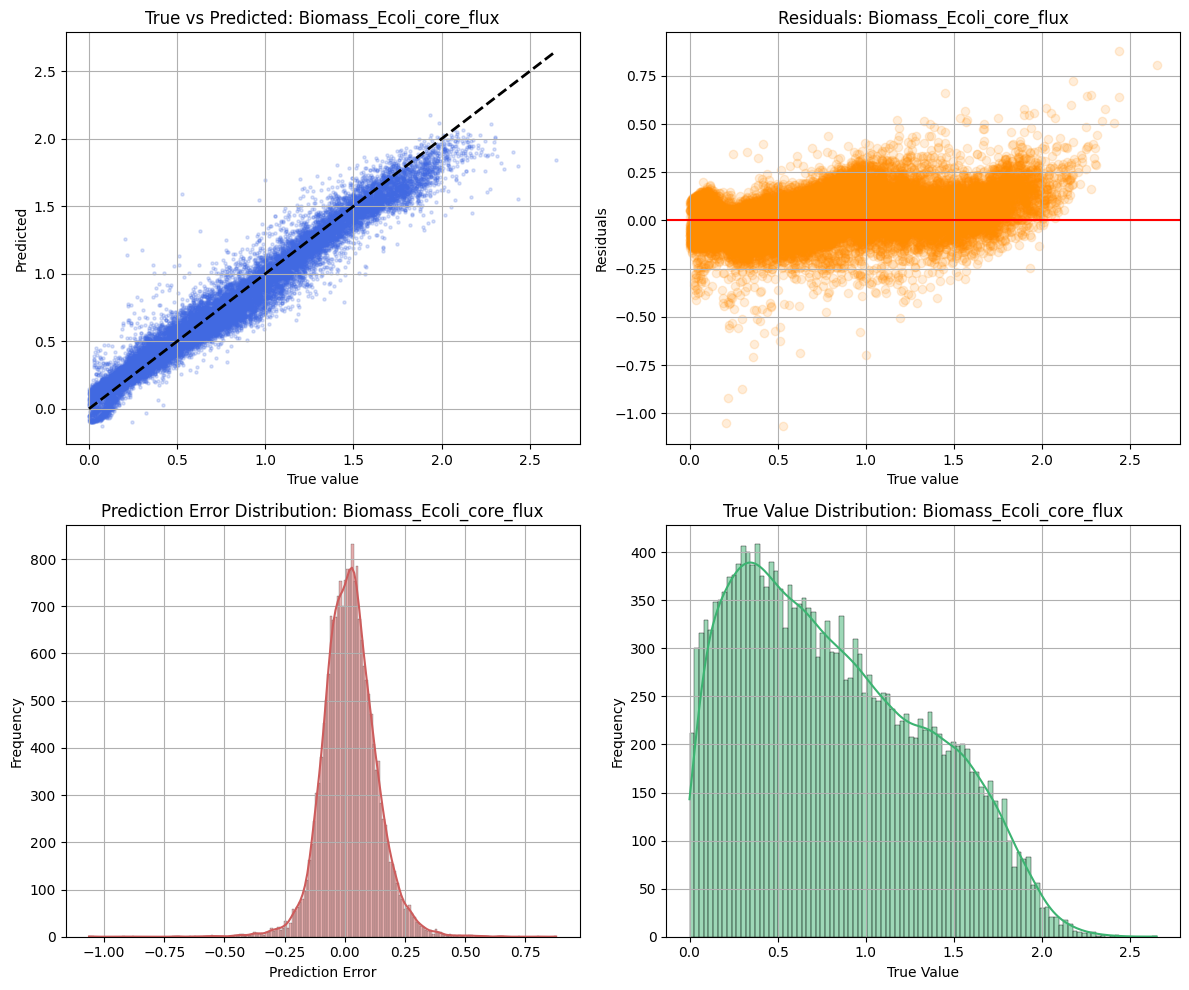

Number of parameters:
29734


In [23]:
train_losses_3222, test_losses_3222, model_3222 = train_model(d_model=32, n_heads=2, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_3222, test_losses_3222, d_model=32, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3222)

plot_flux(model_3222, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3222.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.522067 | Test Loss: 0.375921
Epoch 200/1000 | Train Loss: 0.459119 | Test Loss: 0.330004
Epoch 300/1000 | Train Loss: 0.433752 | Test Loss: 0.318950
Epoch 400/1000 | Train Loss: 0.418197 | Test Loss: 0.303763
Epoch 500/1000 | Train Loss: 0.409201 | Test Loss: 0.303059
Epoch 600/1000 | Train Loss: 0.399808 | Test Loss: 0.298426
Epoch 700/1000 | Train Loss: 0.394104 | Test Loss: 0.290185
Epoch 800/1000 | Train Loss: 0.388750 | Test Loss: 0.293582
Epoch 900/1000 | Train Loss: 0.384962 | Test Loss: 0.282619
Epoch 1000/1000 | Train Loss: 0.380161 | Test Loss: 0.281409
Training Completed.
Training took 101 min 2.6 sec.


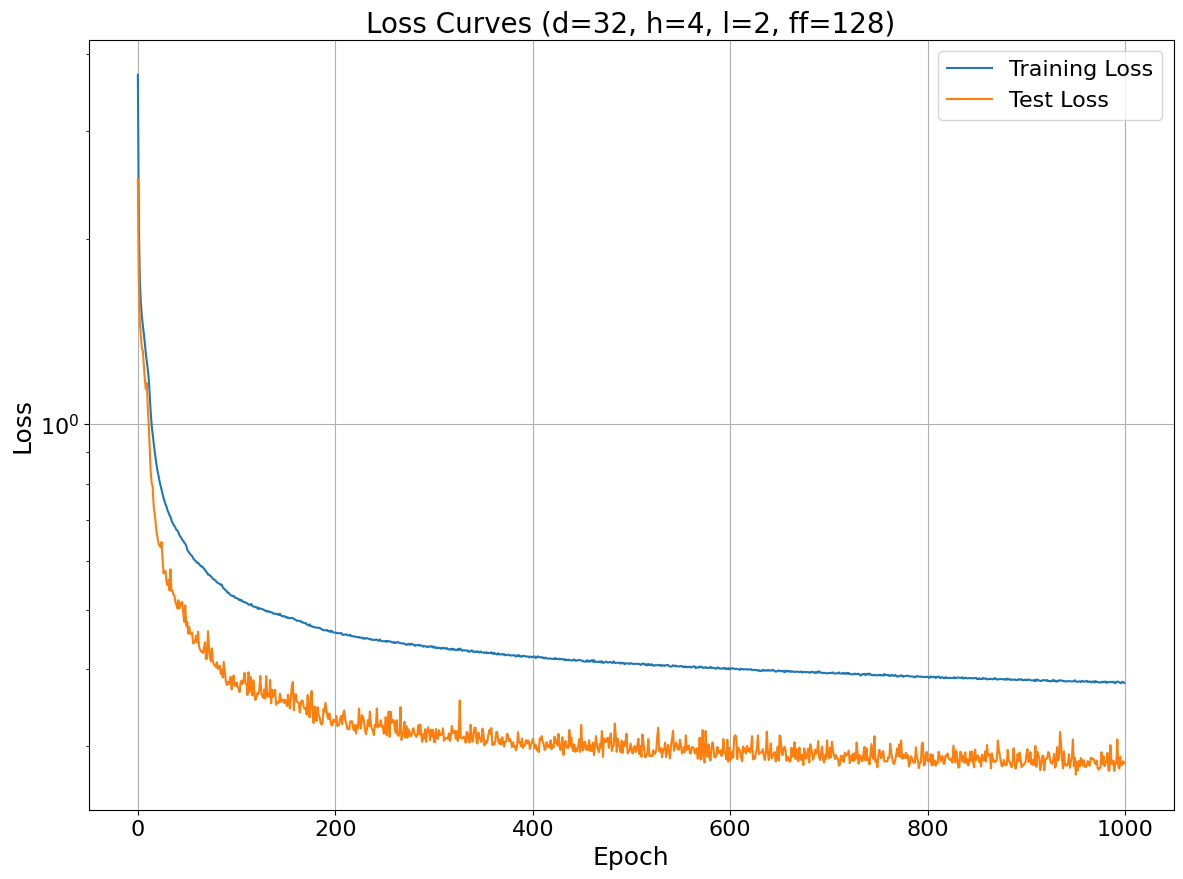

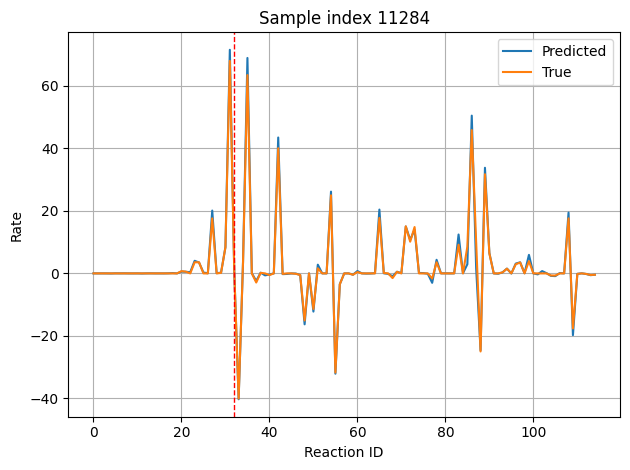

y_pred_outputs.shape: (19606, 95) min/max: -74.77478 108.60875
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.39851117 to 2.593749


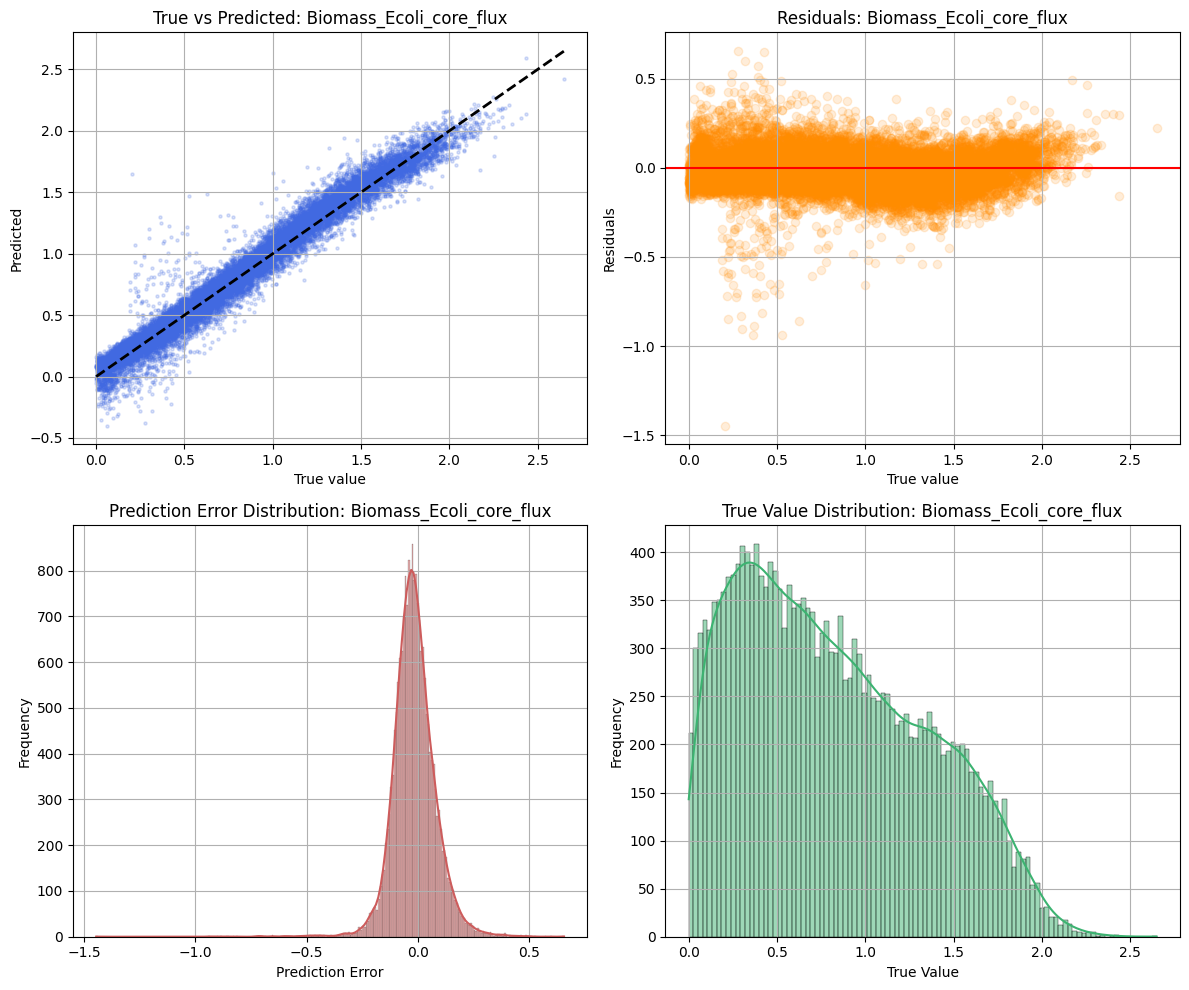

Number of parameters:
29734


In [24]:
train_losses_3242, test_losses_3242, model_3242 = train_model(d_model=32, n_heads=4, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_3242, test_losses_3242, d_model=32, n_heads=4, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3242)

plot_flux(model_3242, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3242.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.396394 | Test Loss: 0.277827
Epoch 200/1000 | Train Loss: 0.335989 | Test Loss: 0.238828
Epoch 300/1000 | Train Loss: 0.305124 | Test Loss: 0.245156
Epoch 400/1000 | Train Loss: 0.287080 | Test Loss: 0.224178
Epoch 500/1000 | Train Loss: 0.276455 | Test Loss: 0.216741
Epoch 600/1000 | Train Loss: 0.269710 | Test Loss: 0.203486
Epoch 700/1000 | Train Loss: 0.262107 | Test Loss: 0.209654
Epoch 800/1000 | Train Loss: 0.256098 | Test Loss: 0.208911
Epoch 900/1000 | Train Loss: 0.253374 | Test Loss: 0.196234
Epoch 1000/1000 | Train Loss: 0.249692 | Test Loss: 0.193138
Training Completed.
Training took 141 min 2.1 sec.


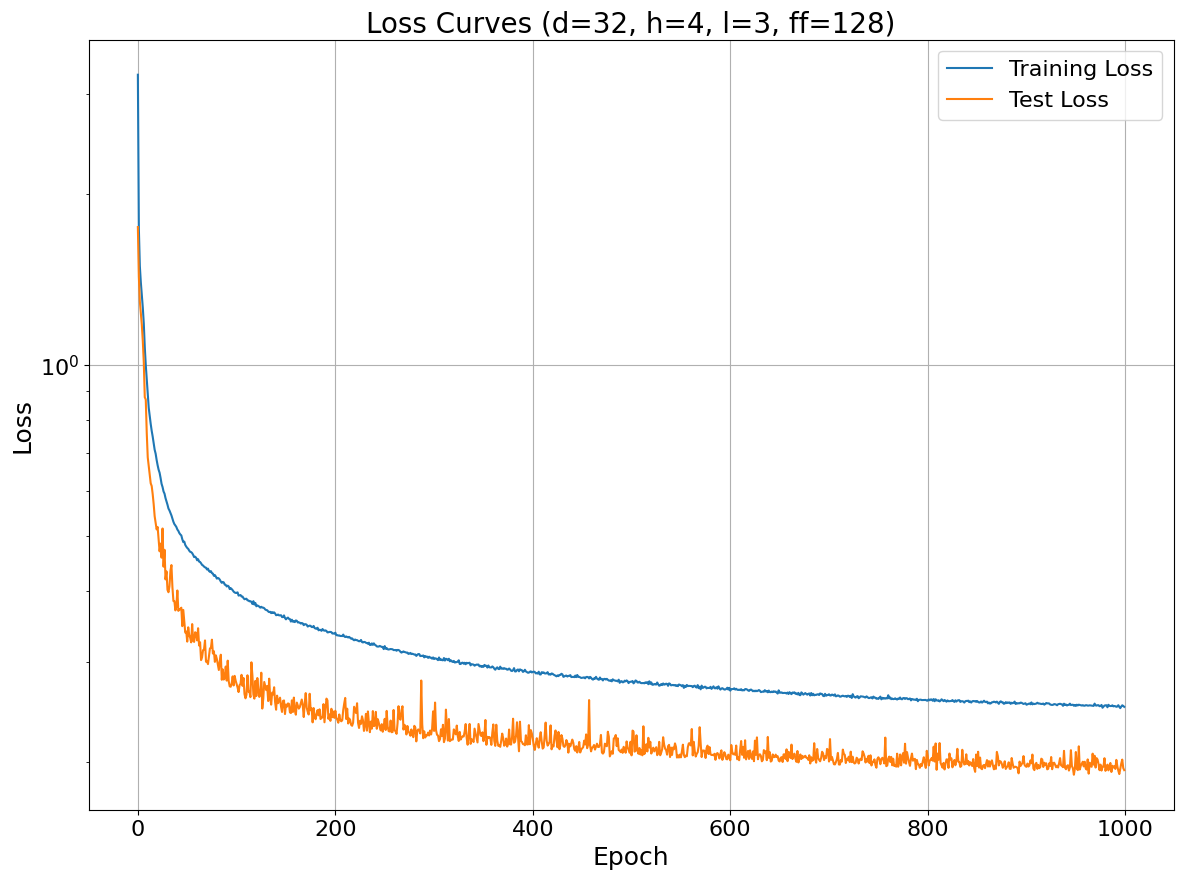

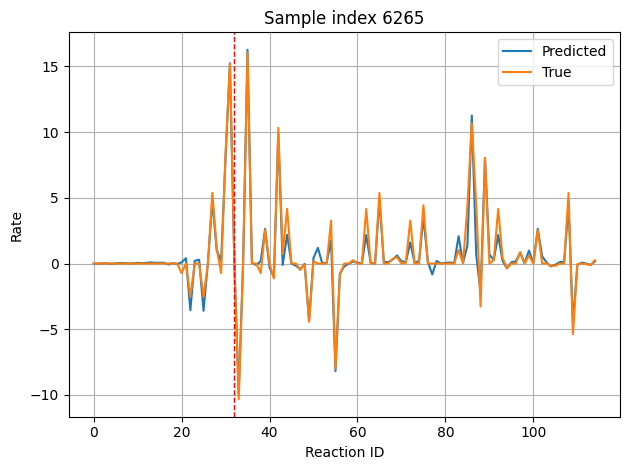

y_pred_outputs.shape: (19606, 95) min/max: -74.71259 108.6432
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.20181458 to 2.7543166


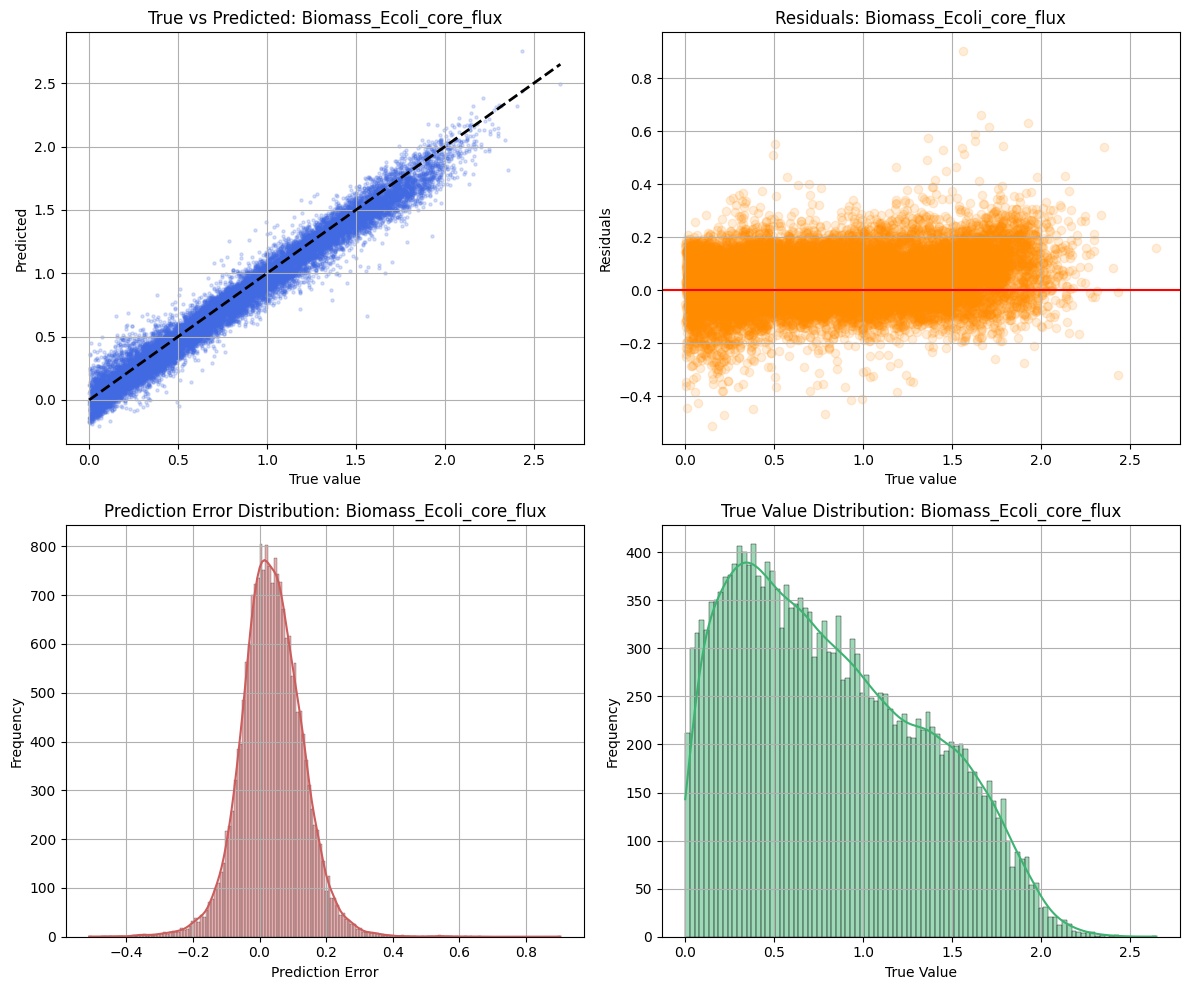

Number of parameters:
42761


In [25]:
train_losses_3243, test_losses_3243, model_3243 = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=128)

plot_loss_curves(train_losses_3243, test_losses_3243, d_model=32, n_heads=4, n_layers=3, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3243)

plot_flux(model_3243, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.343677 | Test Loss: 0.248486
Epoch 200/1000 | Train Loss: 0.301561 | Test Loss: 0.224907
Epoch 300/1000 | Train Loss: 0.282701 | Test Loss: 0.216211
Epoch 400/1000 | Train Loss: 0.270036 | Test Loss: 0.207780
Epoch 500/1000 | Train Loss: 0.258830 | Test Loss: 0.194417
Epoch 600/1000 | Train Loss: 0.251218 | Test Loss: 0.208460
Epoch 700/1000 | Train Loss: 0.245763 | Test Loss: 0.211017
Epoch 800/1000 | Train Loss: 0.240797 | Test Loss: 0.187514
Epoch 900/1000 | Train Loss: 0.235569 | Test Loss: 0.189951
Epoch 1000/1000 | Train Loss: 0.234305 | Test Loss: 0.187720
Training Completed.
Training took 157 min 11.9 sec.


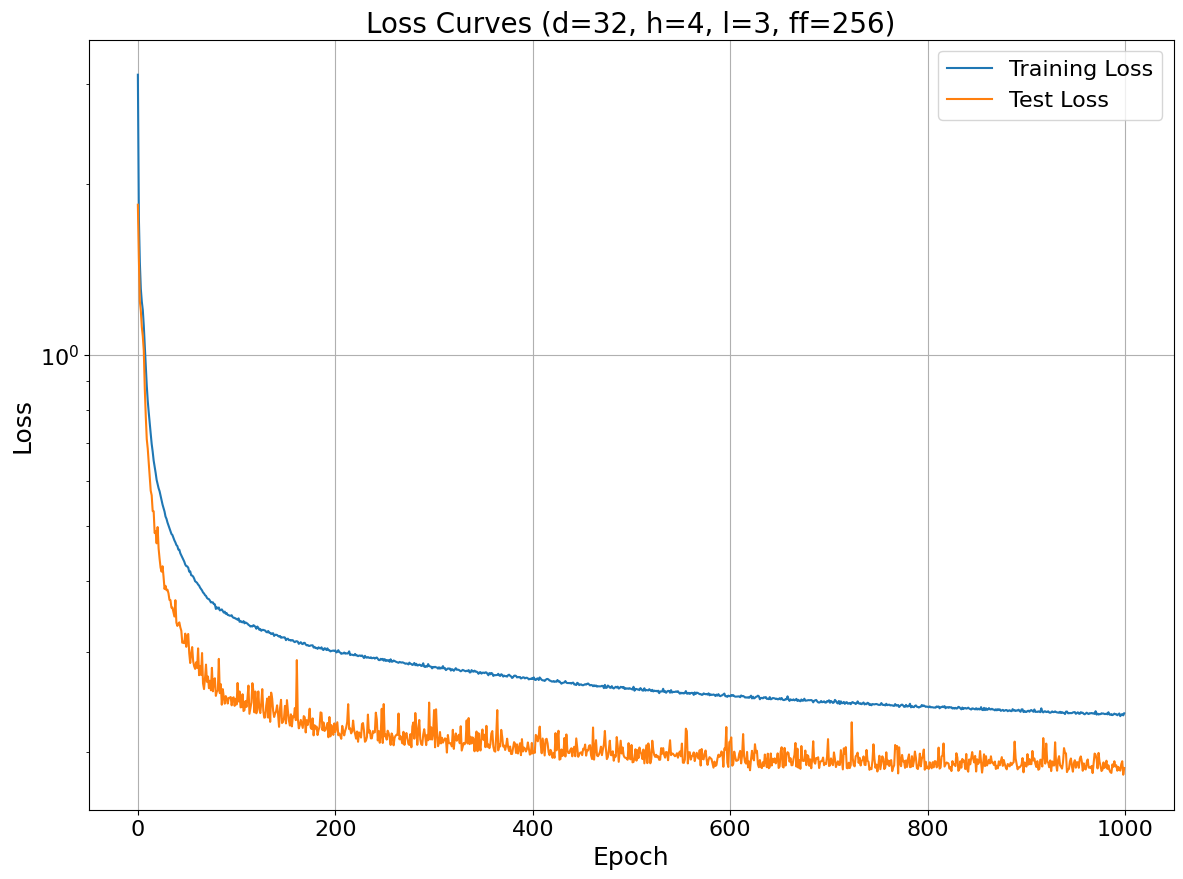

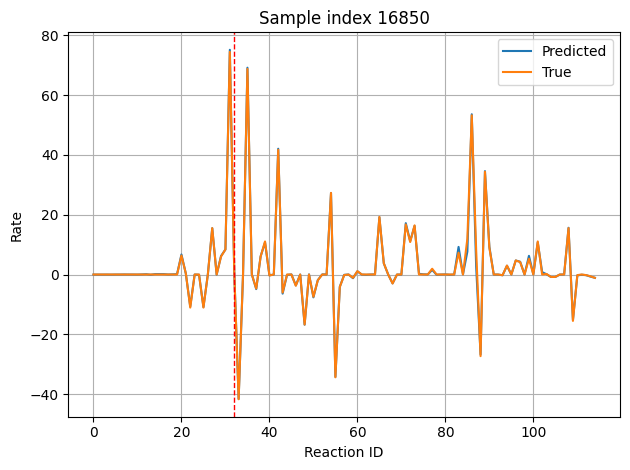

y_pred_outputs.shape: (19606, 95) min/max: -76.14158 109.79433
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.17955479 to 2.8451807


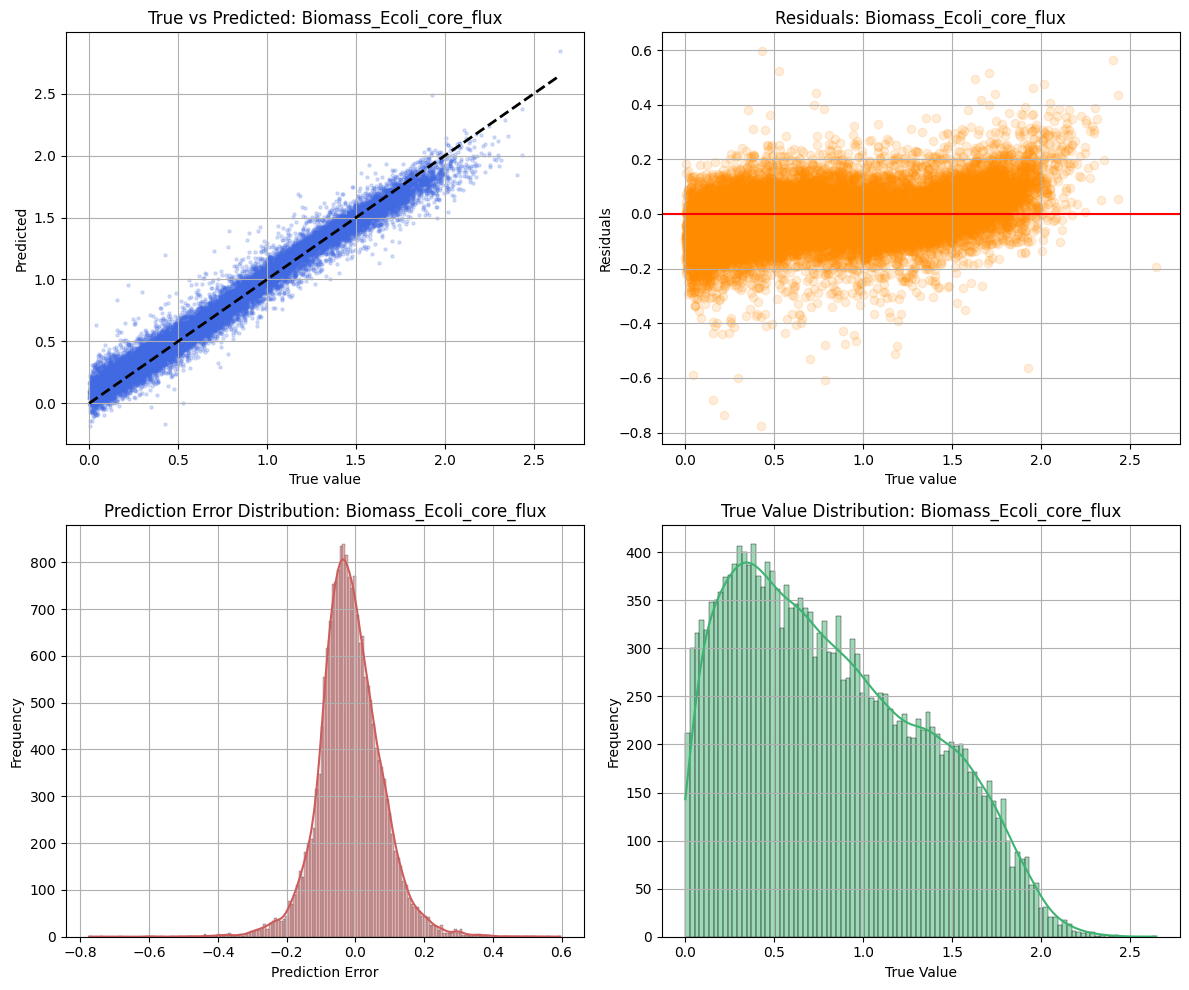

Number of parameters:
68489


In [26]:
train_losses_3243_256, test_losses_3243_256, model_3243_256 = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=256)

plot_loss_curves(train_losses_3243_256, test_losses_3243_256, d_model=32, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_3243_256)

plot_flux(model_3243_256, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.444936 | Test Loss: 0.336652
Epoch 200/1000 | Train Loss: 0.380599 | Test Loss: 0.292240
Epoch 300/1000 | Train Loss: 0.358663 | Test Loss: 0.279537
Epoch 400/1000 | Train Loss: 0.343012 | Test Loss: 0.267161
Epoch 500/1000 | Train Loss: 0.332918 | Test Loss: 0.254408
Epoch 600/1000 | Train Loss: 0.324574 | Test Loss: 0.256907
Epoch 700/1000 | Train Loss: 0.319045 | Test Loss: 0.253025
Epoch 800/1000 | Train Loss: 0.313777 | Test Loss: 0.250523
Epoch 900/1000 | Train Loss: 0.310251 | Test Loss: 0.241355
Epoch 1000/1000 | Train Loss: 0.307197 | Test Loss: 0.239734
Training Completed.
Training took 111 min 17.9 sec.


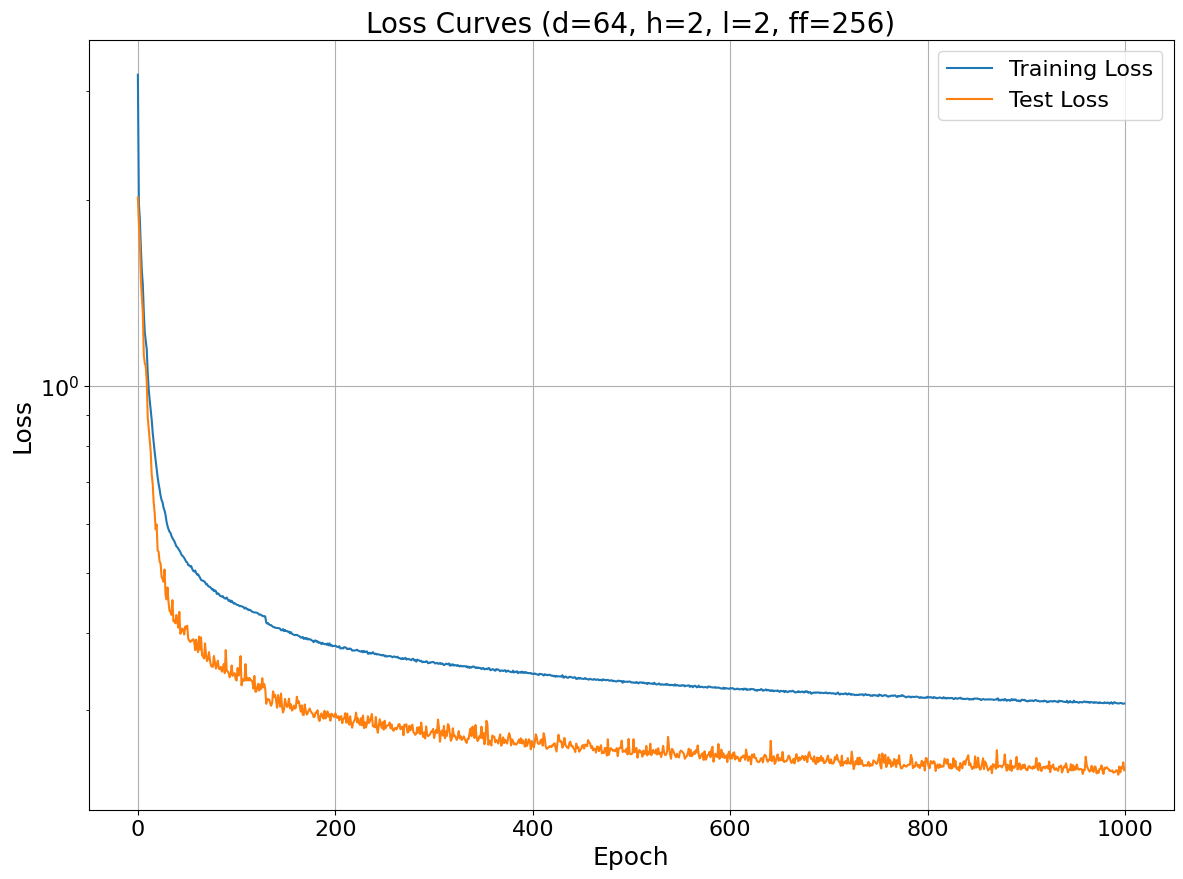

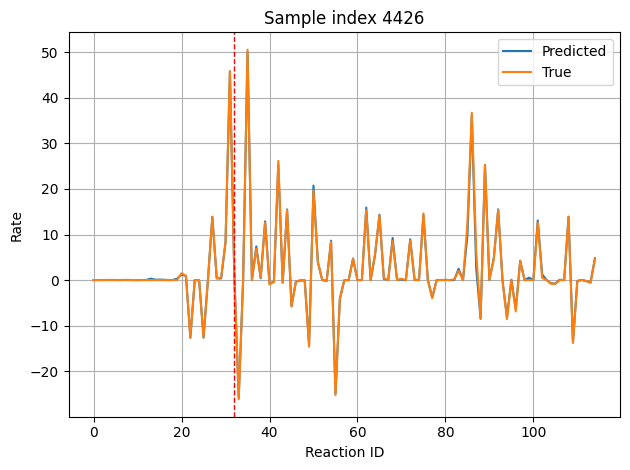

y_pred_outputs.shape: (19606, 95) min/max: -76.47186 108.0755
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: 0.0017970502 to 2.302087


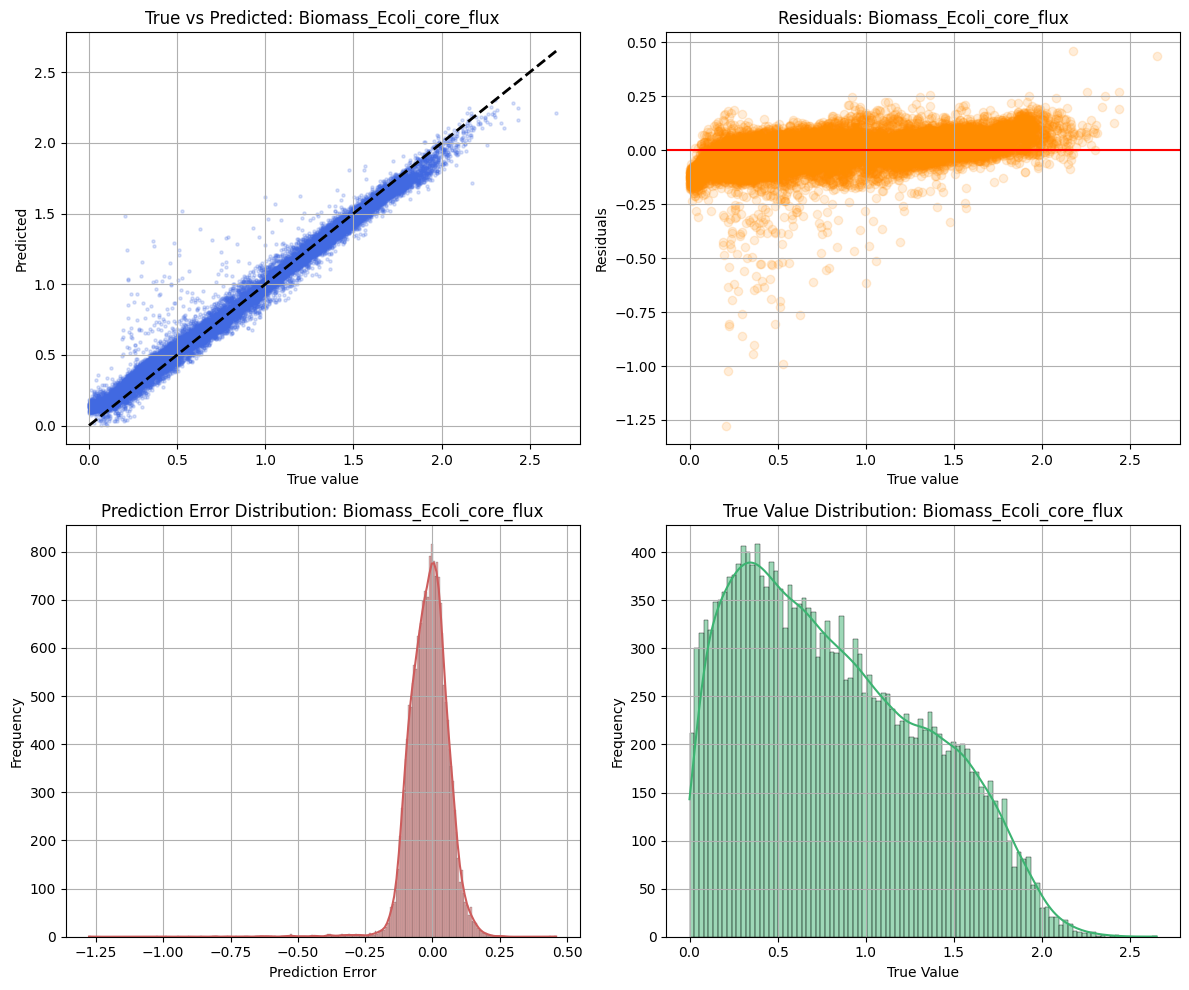

Number of parameters:
108614


In [27]:
train_losses_6422_256, test_losses_6422_256, model_6422_256 = train_model(d_model=64, n_heads=2, n_layers=2, d_ff=256)

plot_loss_curves(train_losses_6422_256, test_losses_6422_256, d_model=64, n_heads=2, n_layers=2, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6422_256)

plot_flux(model_6422_256, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6422_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.391166 | Test Loss: 0.321401
Epoch 200/1000 | Train Loss: 0.346487 | Test Loss: 0.264864
Epoch 300/1000 | Train Loss: 0.327442 | Test Loss: 0.293135
Epoch 400/1000 | Train Loss: 0.312970 | Test Loss: 0.241359
Epoch 500/1000 | Train Loss: 0.304885 | Test Loss: 0.254345
Epoch 600/1000 | Train Loss: 0.296916 | Test Loss: 0.237126
Epoch 700/1000 | Train Loss: 0.293020 | Test Loss: 0.245404
Epoch 800/1000 | Train Loss: 0.287115 | Test Loss: 0.231125
Epoch 900/1000 | Train Loss: 0.282417 | Test Loss: 0.223252
Epoch 1000/1000 | Train Loss: 0.280418 | Test Loss: 0.235505
Training Completed.
Training took 130 min 19.6 sec.


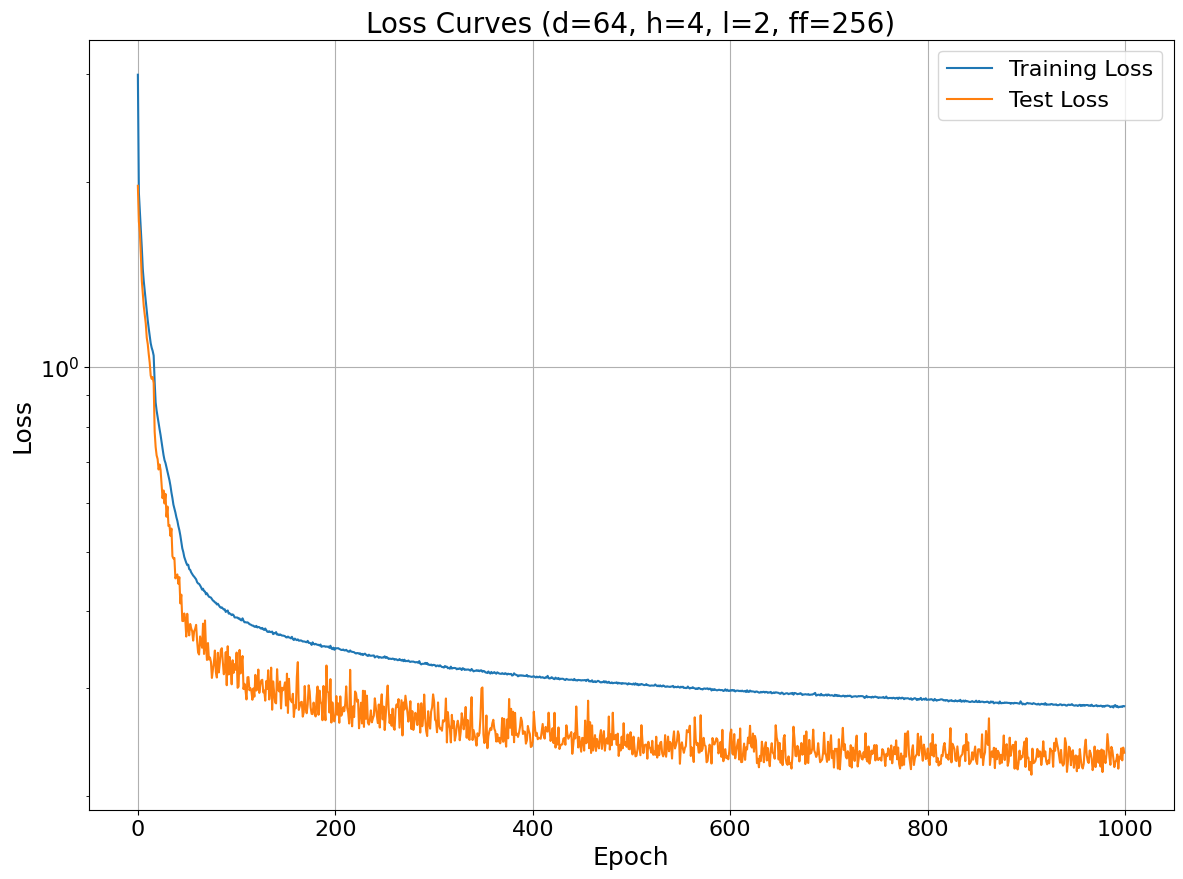

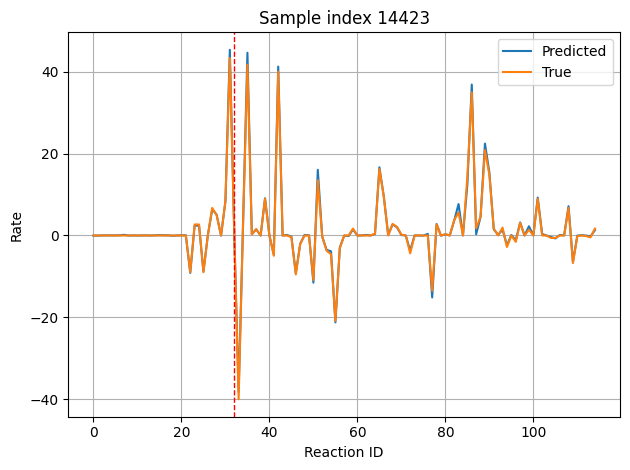

y_pred_outputs.shape: (19606, 95) min/max: -74.84825 109.764175
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.066274345 to 2.5087838


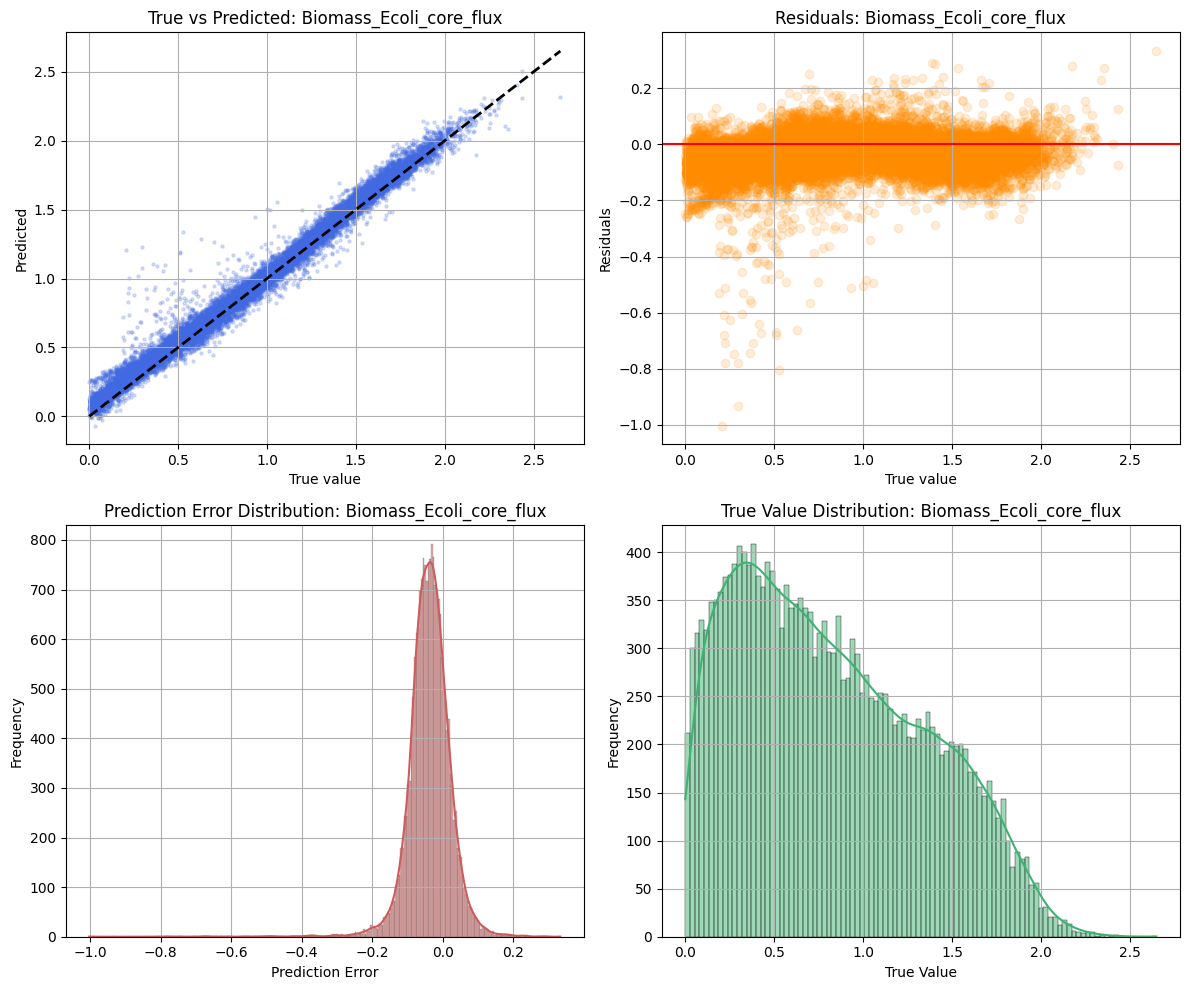

Number of parameters:
108614


In [28]:
train_losses_6442_256, test_losses_6442_256, model_6442_256 = train_model(d_model=64, n_heads=4, n_layers=2, d_ff=256)

plot_loss_curves(train_losses_6442_256, test_losses_6442_256, d_model=64, n_heads=4, n_layers=2, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6442_256)

plot_flux(model_6442_256, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6442_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.270199 | Test Loss: 0.213650
Epoch 200/1000 | Train Loss: 0.238443 | Test Loss: 0.193666
Epoch 300/1000 | Train Loss: 0.223114 | Test Loss: 0.189705
Epoch 400/1000 | Train Loss: 0.214103 | Test Loss: 0.182398
Epoch 500/1000 | Train Loss: 0.206254 | Test Loss: 0.181148
Epoch 600/1000 | Train Loss: 0.201141 | Test Loss: 0.174987
Epoch 700/1000 | Train Loss: 0.197371 | Test Loss: 0.172321
Epoch 800/1000 | Train Loss: 0.193882 | Test Loss: 0.173130
Epoch 900/1000 | Train Loss: 0.191392 | Test Loss: 0.173917
Epoch 1000/1000 | Train Loss: 0.188853 | Test Loss: 0.176263
Training Completed.
Training took 189 min 35.6 sec.


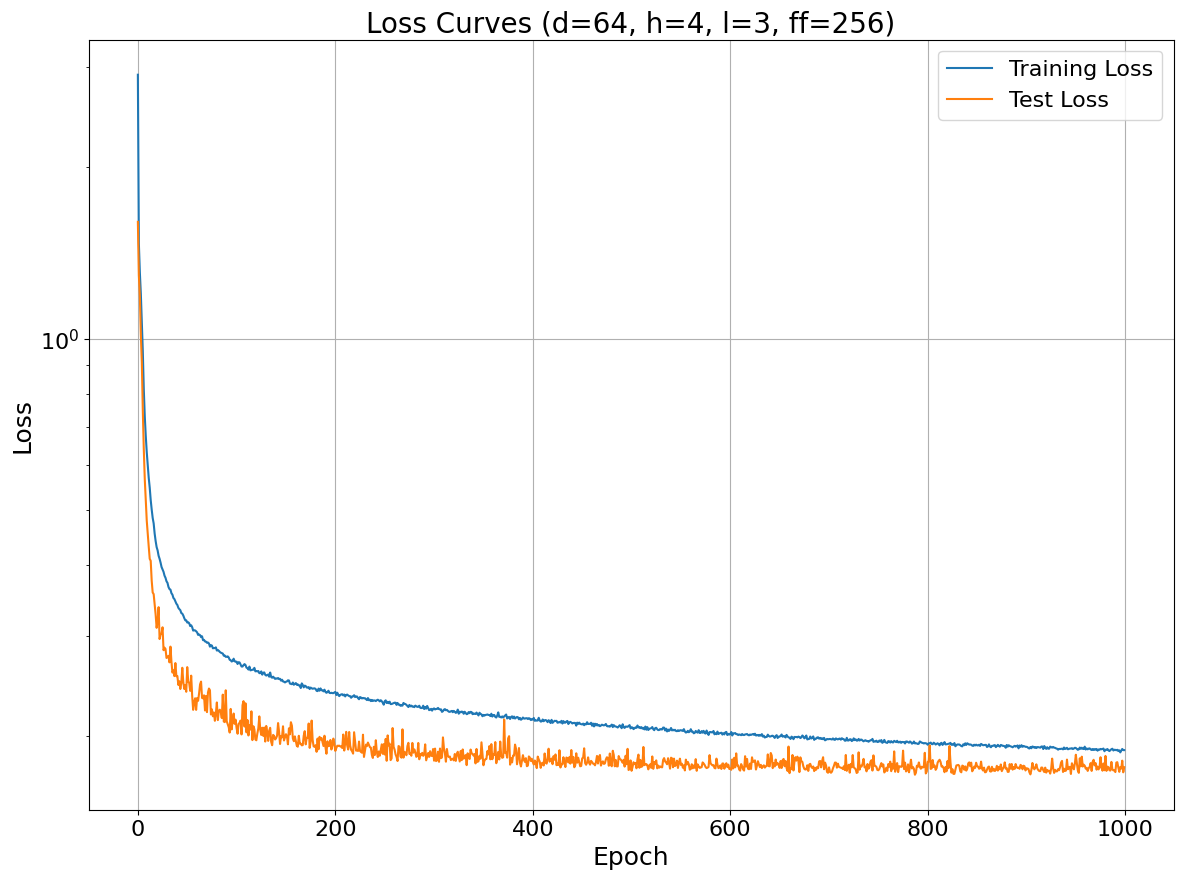

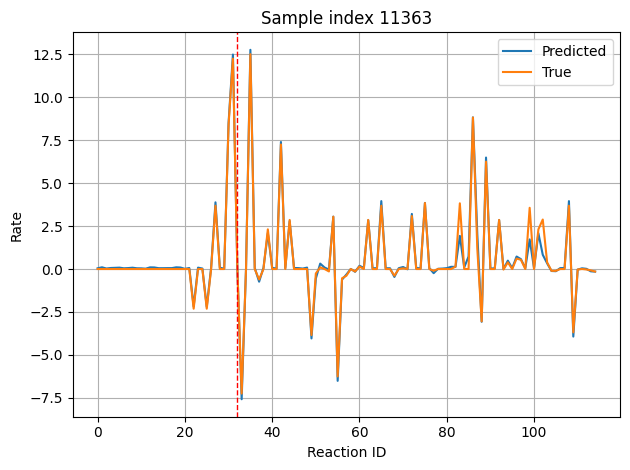

y_pred_outputs.shape: (19606, 95) min/max: -77.37768 109.86136
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.15006053 to 2.3862276


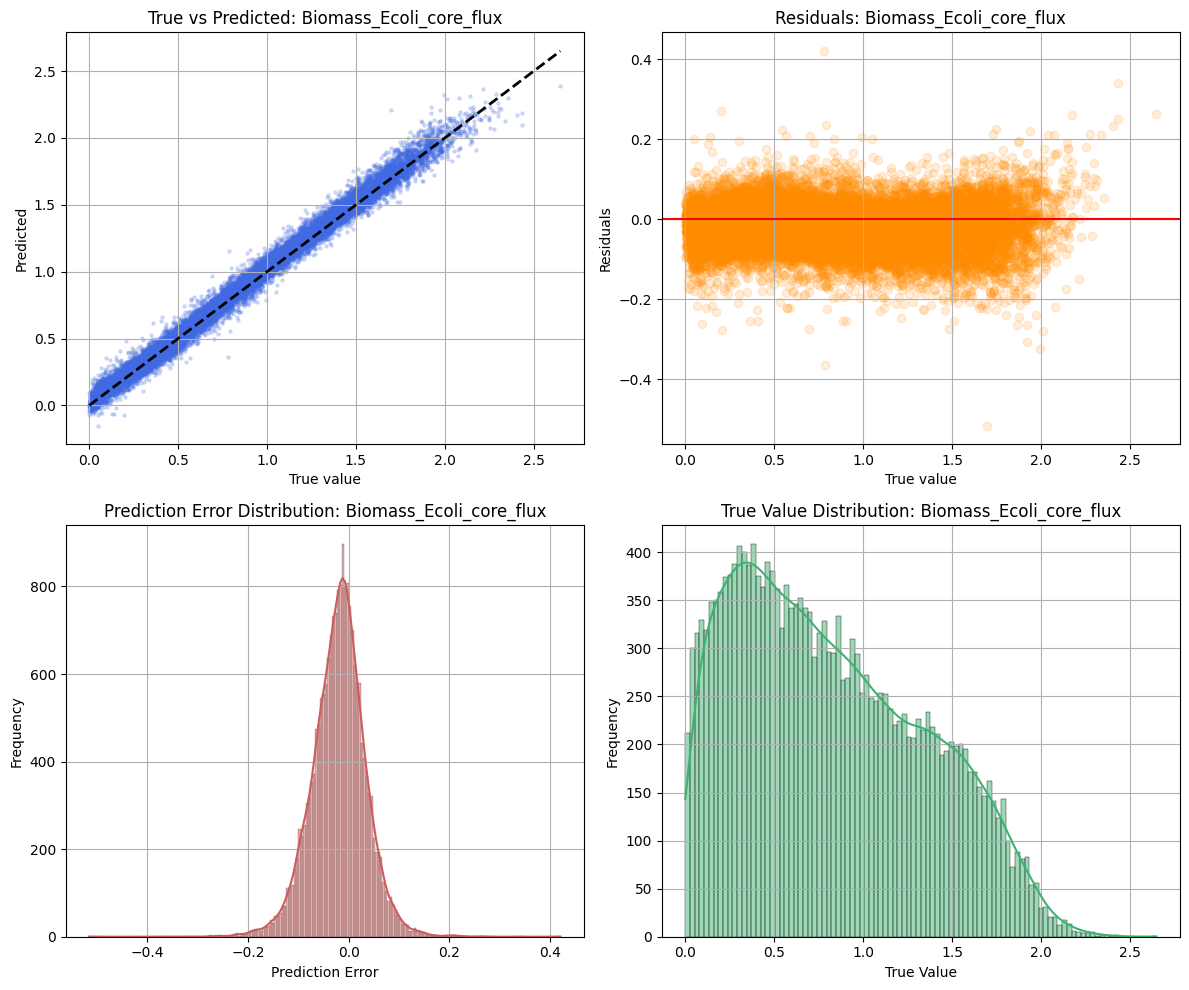

Number of parameters:
159241


In [29]:
train_losses_6443_256, test_losses_6443_256, model_6443_256 = train_model(d_model=64, n_heads=4, n_layers=3, d_ff=256)

plot_loss_curves(train_losses_6443_256, test_losses_6443_256, d_model=64, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6443_256)

plot_flux(model_6443_256, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6443_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.261068 | Test Loss: 0.203098
Epoch 200/1000 | Train Loss: 0.225363 | Test Loss: 0.185524
Epoch 300/1000 | Train Loss: 0.212495 | Test Loss: 0.178401
Epoch 400/1000 | Train Loss: 0.202347 | Test Loss: 0.178596
Epoch 500/1000 | Train Loss: 0.197688 | Test Loss: 0.173165
Epoch 600/1000 | Train Loss: 0.192297 | Test Loss: 0.179828
Epoch 700/1000 | Train Loss: 0.188713 | Test Loss: 0.172427
Epoch 800/1000 | Train Loss: 0.185903 | Test Loss: 0.173939
Epoch 900/1000 | Train Loss: 0.182119 | Test Loss: 0.174861
Epoch 1000/1000 | Train Loss: 0.179114 | Test Loss: 0.171734
Training Completed.
Training took 172 min 58.1 sec.


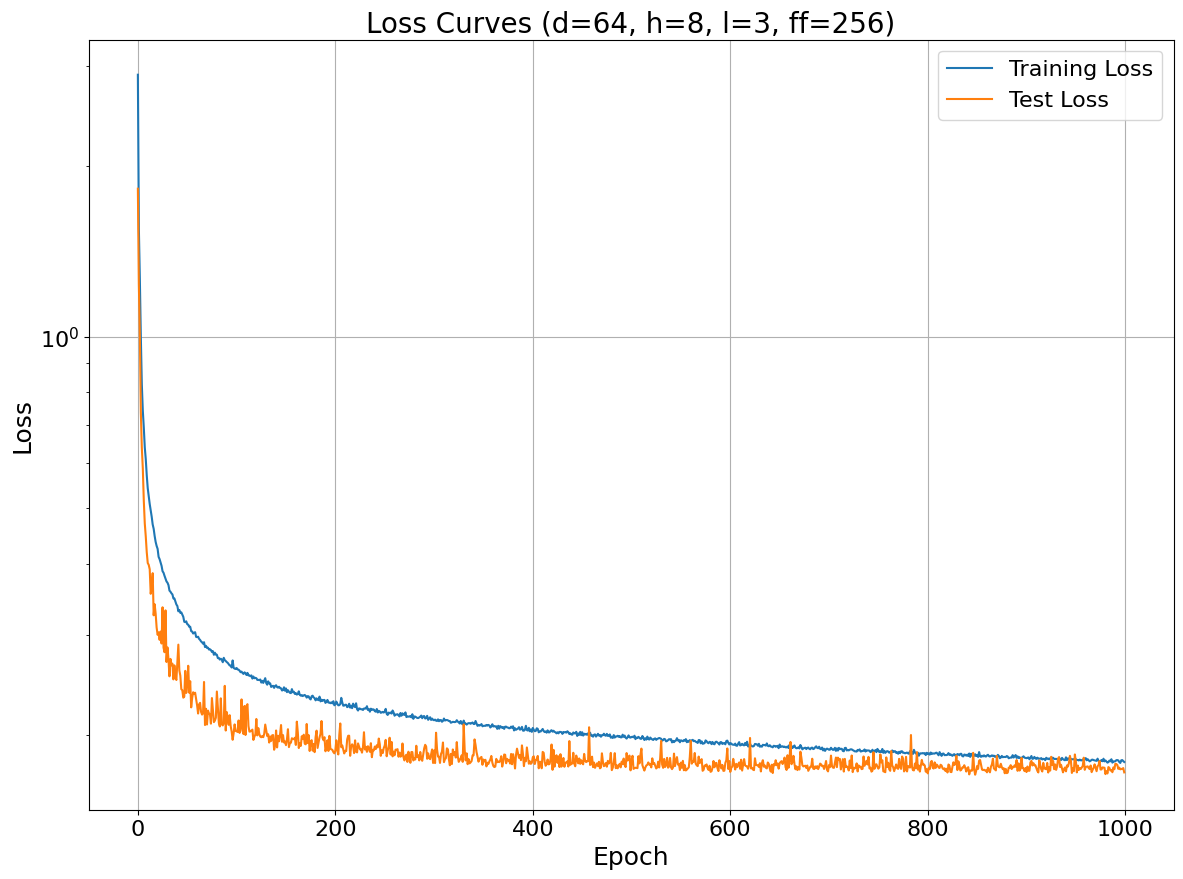

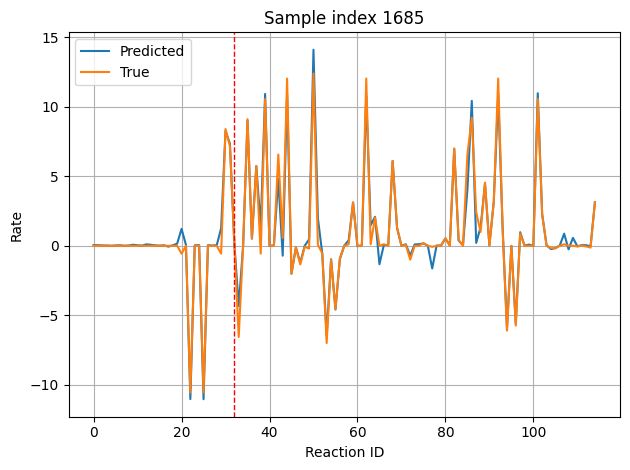

y_pred_outputs.shape: (19606, 95) min/max: -76.11075 108.9737
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.09594238 to 2.8695395


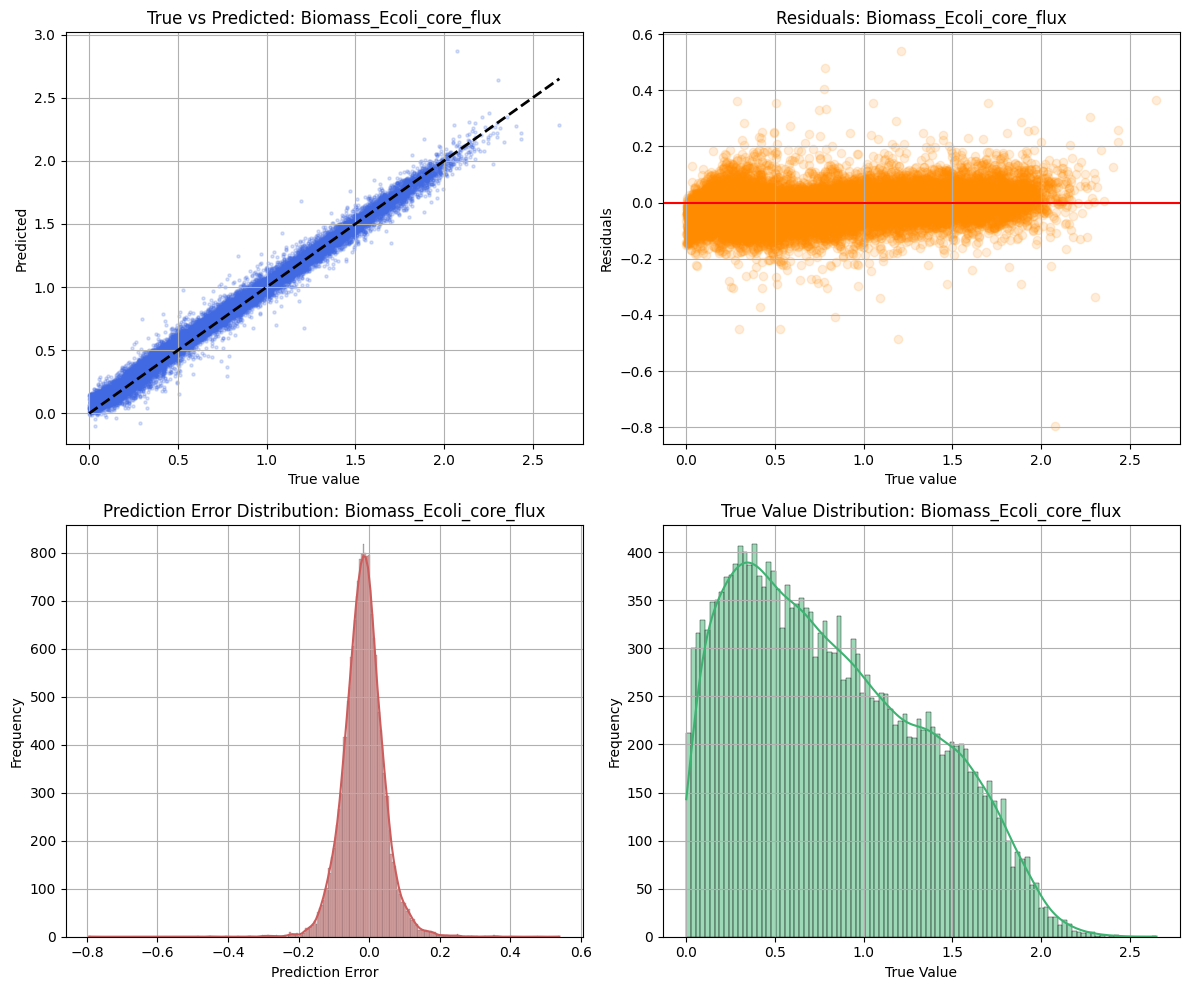

Number of parameters:
159241


In [34]:
train_losses_6483_256, test_losses_6483_256, model_6483_256 = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=256)

plot_loss_curves(train_losses_6483_256, test_losses_6483_256, d_model=64, n_heads=8, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6483_256)

plot_flux(model_6483_256, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.232758 | Test Loss: 0.194301
Epoch 200/1000 | Train Loss: 0.208321 | Test Loss: 0.183275
Epoch 300/1000 | Train Loss: 0.195346 | Test Loss: 0.179597
Epoch 400/1000 | Train Loss: 0.188878 | Test Loss: 0.181279
Epoch 500/1000 | Train Loss: 0.182613 | Test Loss: 0.172616
Epoch 600/1000 | Train Loss: 0.177315 | Test Loss: 0.176830
Epoch 700/1000 | Train Loss: 0.172074 | Test Loss: 0.184498
Epoch 800/1000 | Train Loss: 0.168665 | Test Loss: 0.179459
Epoch 900/1000 | Train Loss: 0.164651 | Test Loss: 0.181759
Epoch 1000/1000 | Train Loss: 0.159871 | Test Loss: 0.183511
Training Completed.
Training took 195 min 4.0 sec.


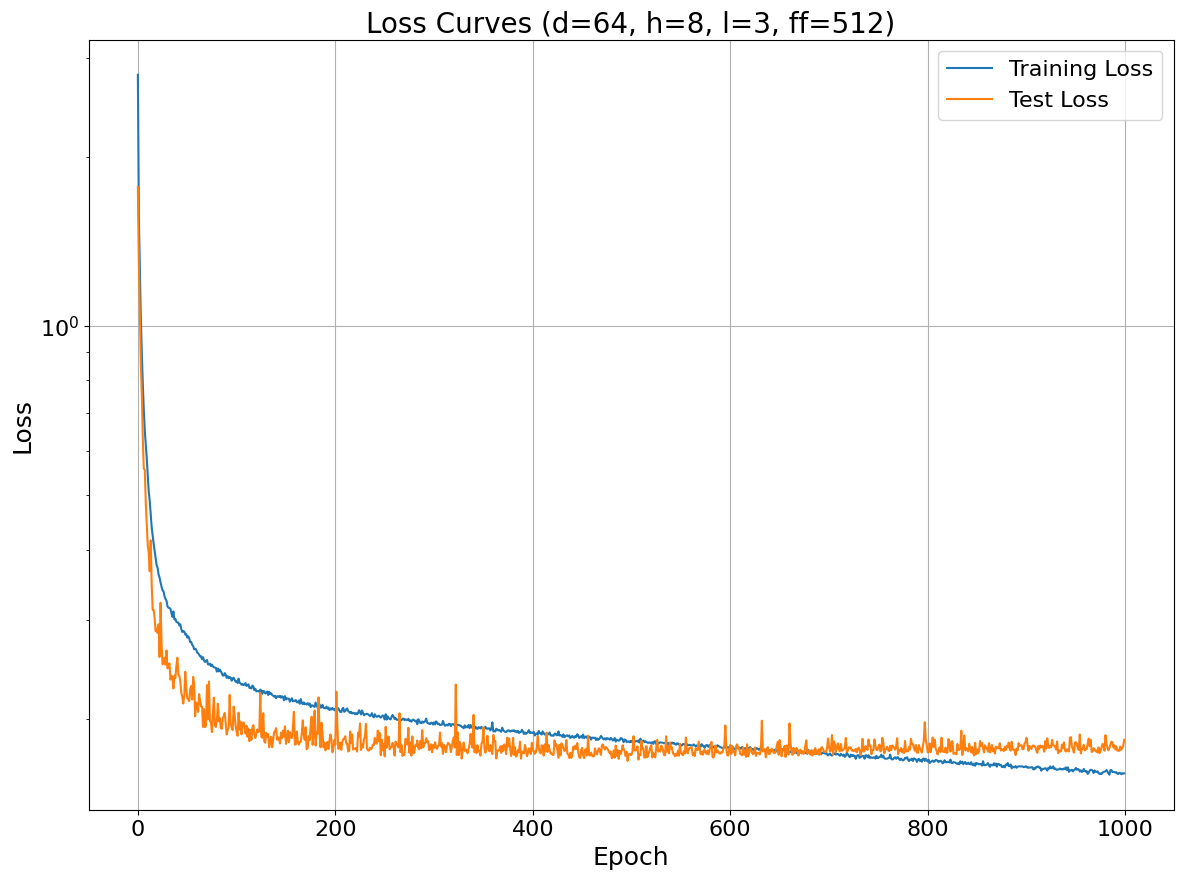

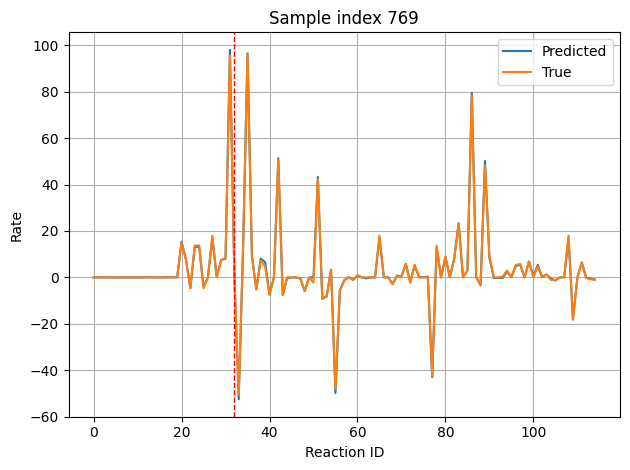

y_pred_outputs.shape: (19606, 95) min/max: -78.46122 109.48212
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.1703336 to 2.652985


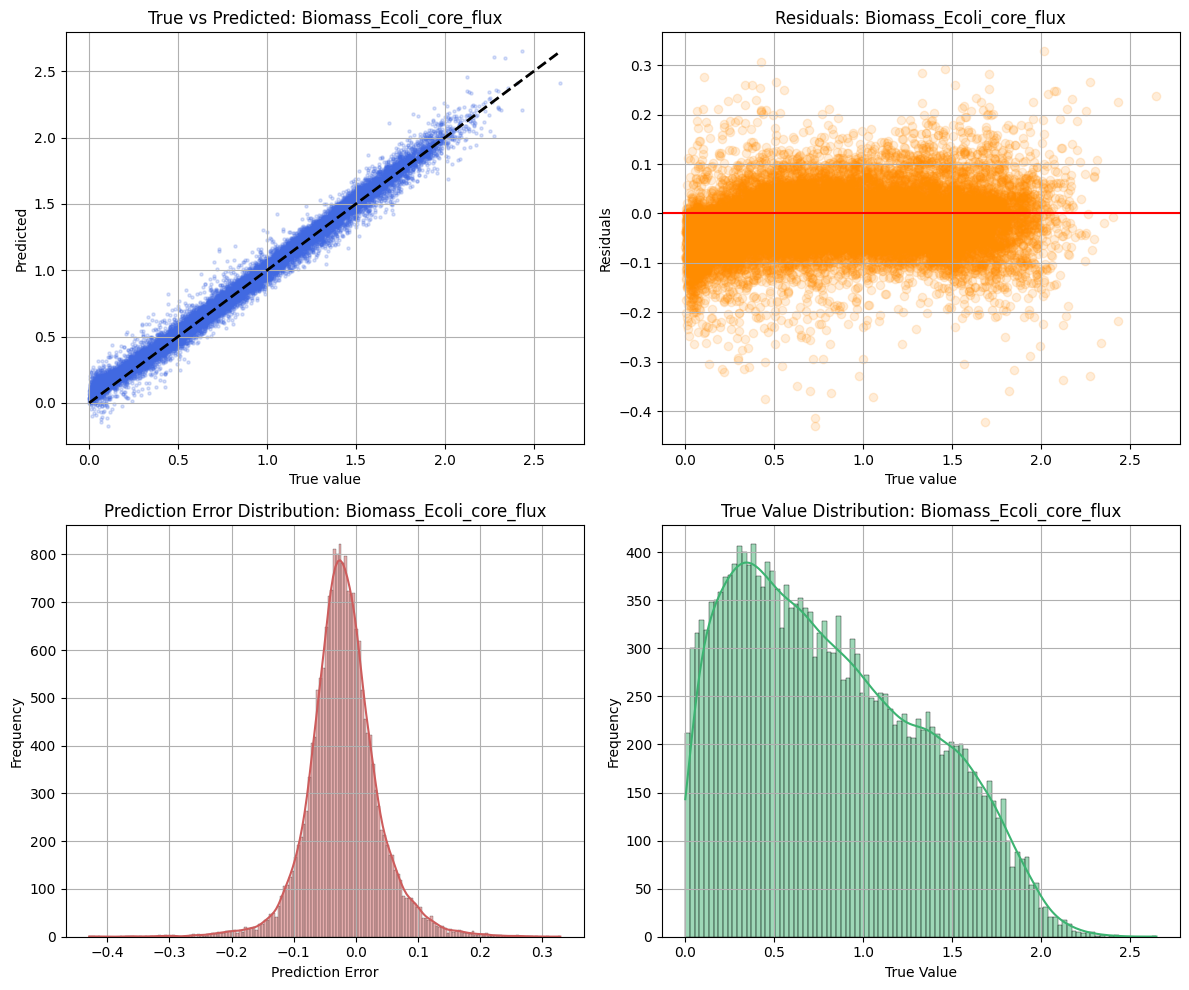

Number of parameters:
259849


In [35]:
train_losses_6483_512, test_losses_6483_512, model_6483_512 = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=512)

plot_loss_curves(train_losses_6483_512, test_losses_6483_512, d_model=64, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_6483_512)

plot_flux(model_6483_512, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_512.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.230000 | Test Loss: 0.202835
Epoch 200/1000 | Train Loss: 0.203999 | Test Loss: 0.176901
Epoch 300/1000 | Train Loss: 0.189885 | Test Loss: 0.176669
Epoch 400/1000 | Train Loss: 0.181343 | Test Loss: 0.179493
Epoch 500/1000 | Train Loss: 0.175671 | Test Loss: 0.172782
Epoch 600/1000 | Train Loss: 0.168912 | Test Loss: 0.171698
Epoch 700/1000 | Train Loss: 0.165652 | Test Loss: 0.179581
Epoch 800/1000 | Train Loss: 0.159405 | Test Loss: 0.189892
Epoch 900/1000 | Train Loss: 0.152361 | Test Loss: 0.179323
Epoch 1000/1000 | Train Loss: 0.148461 | Test Loss: 0.180860
Training Completed.
Training took 242 min 57.6 sec.


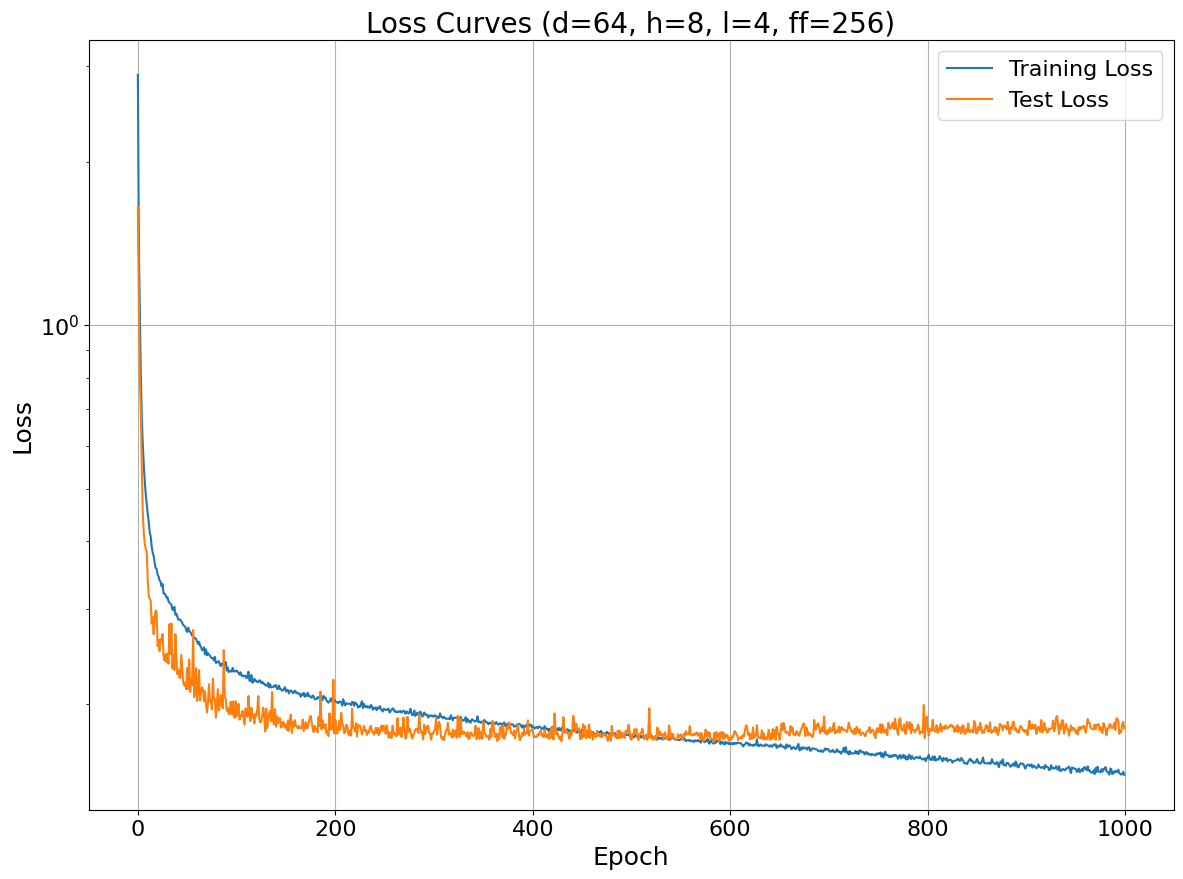

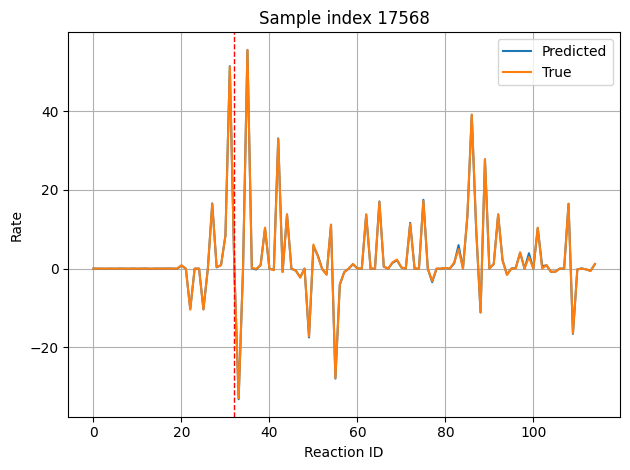

y_pred_outputs.shape: (19606, 95) min/max: -77.54924 109.642624
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.3223392 to 2.5499346


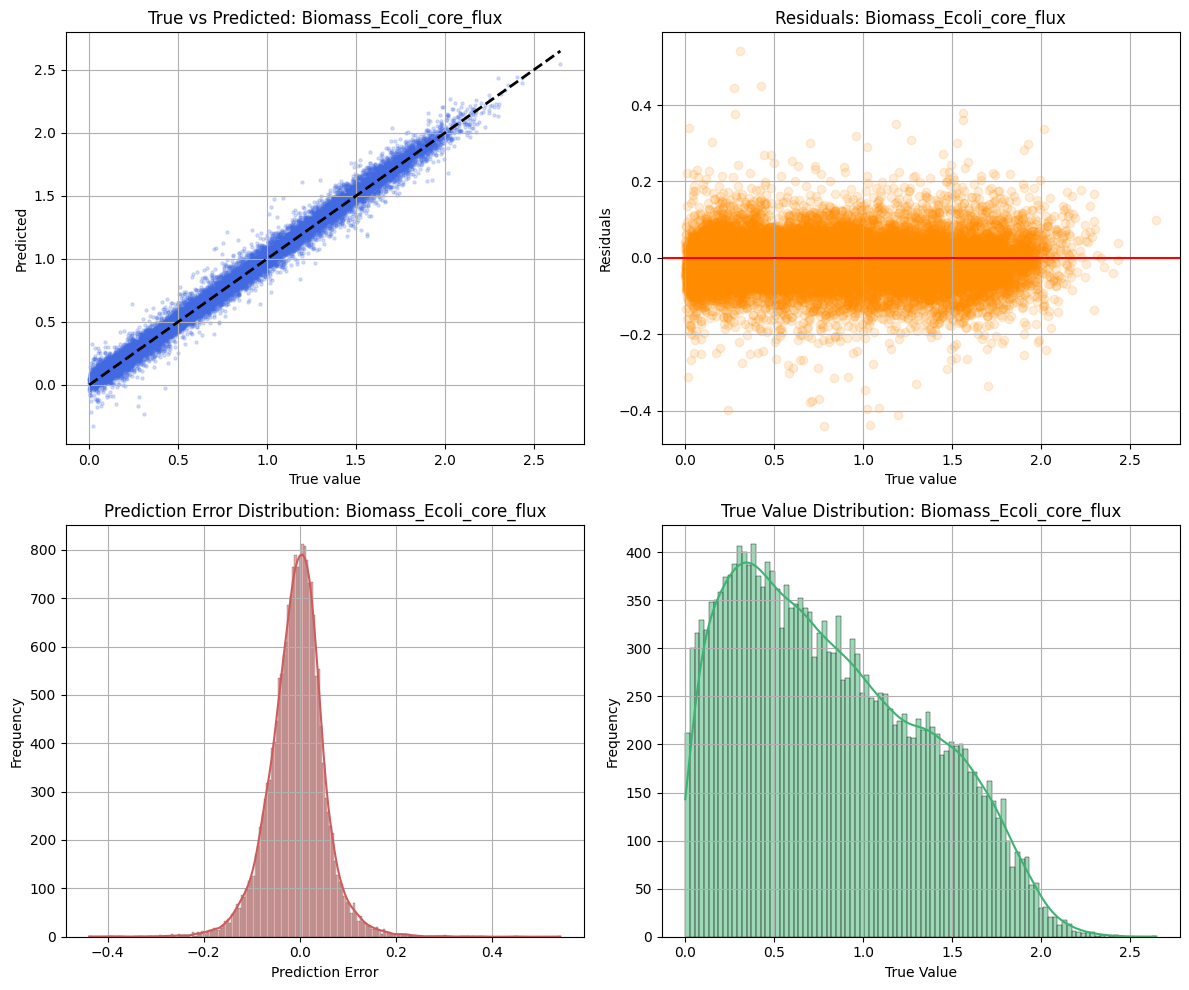

Number of parameters:
209868


In [40]:
train_losses_6484_256, test_losses_6484_256, model_6484_256 = train_model(d_model=64, n_heads=8, n_layers=4, d_ff=256)

plot_loss_curves(train_losses_6484_256, test_losses_6484_256, d_model=64, n_heads=8, n_layers=4, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6484_256)

plot_flux(model_6484_256, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6484_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.323068 | Test Loss: 0.257497
Epoch 200/1000 | Train Loss: 0.287157 | Test Loss: 0.233924
Epoch 300/1000 | Train Loss: 0.269384 | Test Loss: 0.216331
Epoch 400/1000 | Train Loss: 0.259094 | Test Loss: 0.207690
Epoch 500/1000 | Train Loss: 0.252034 | Test Loss: 0.204410
Epoch 600/1000 | Train Loss: 0.245847 | Test Loss: 0.203564
Epoch 700/1000 | Train Loss: 0.243486 | Test Loss: 0.200441
Epoch 800/1000 | Train Loss: 0.239930 | Test Loss: 0.199521
Epoch 900/1000 | Train Loss: 0.237275 | Test Loss: 0.195336
Epoch 1000/1000 | Train Loss: 0.236033 | Test Loss: 0.194494
Training Completed.
Training took 118 min 58.2 sec.


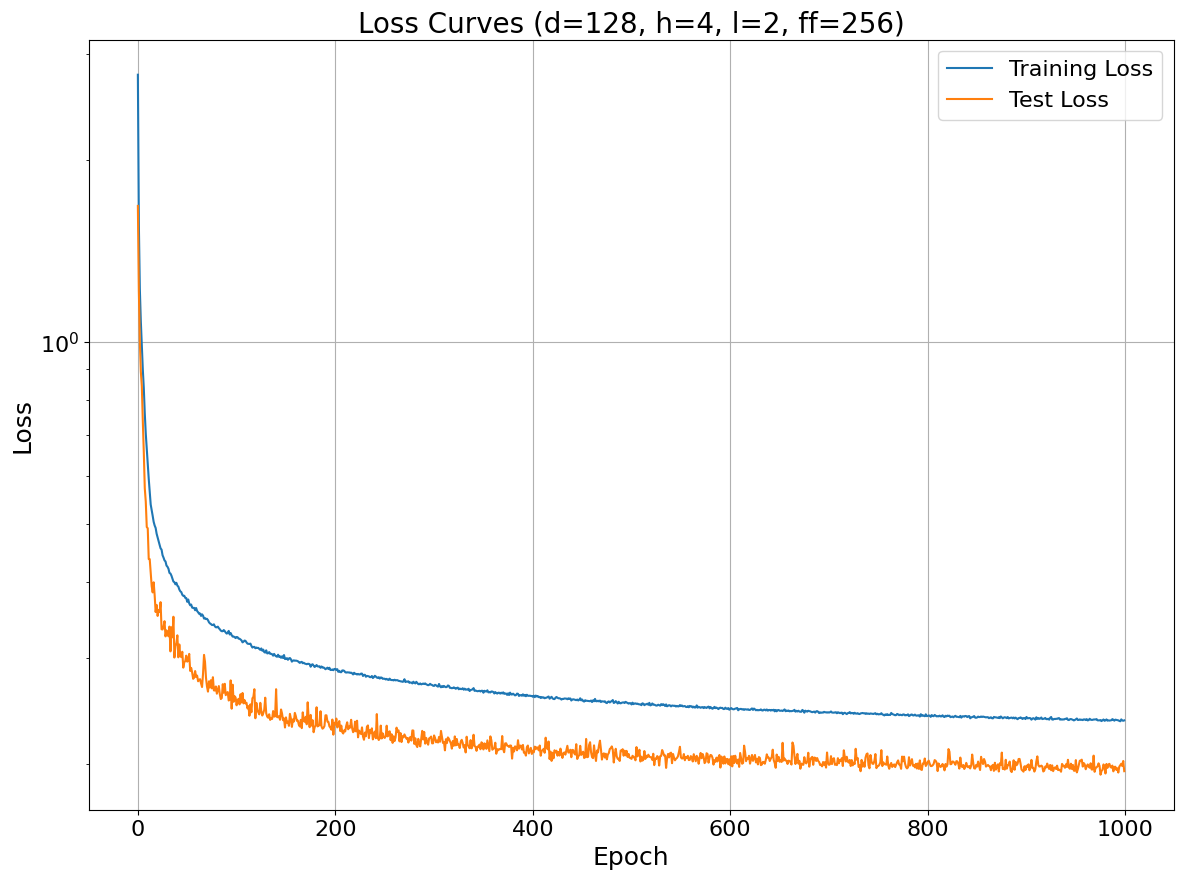

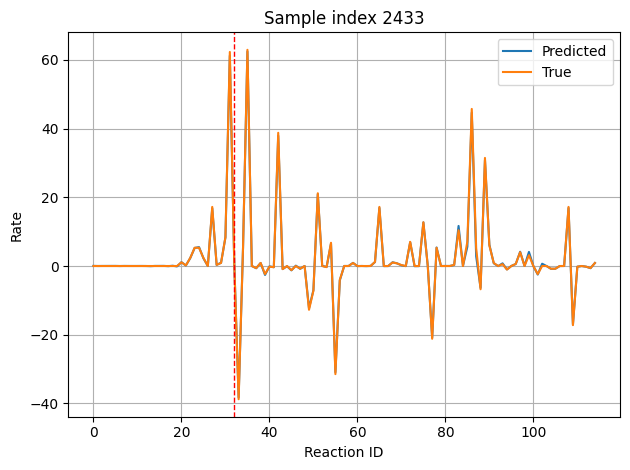

y_pred_outputs.shape: (19606, 95) min/max: -75.97629 108.047806
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.06548327 to 2.381632


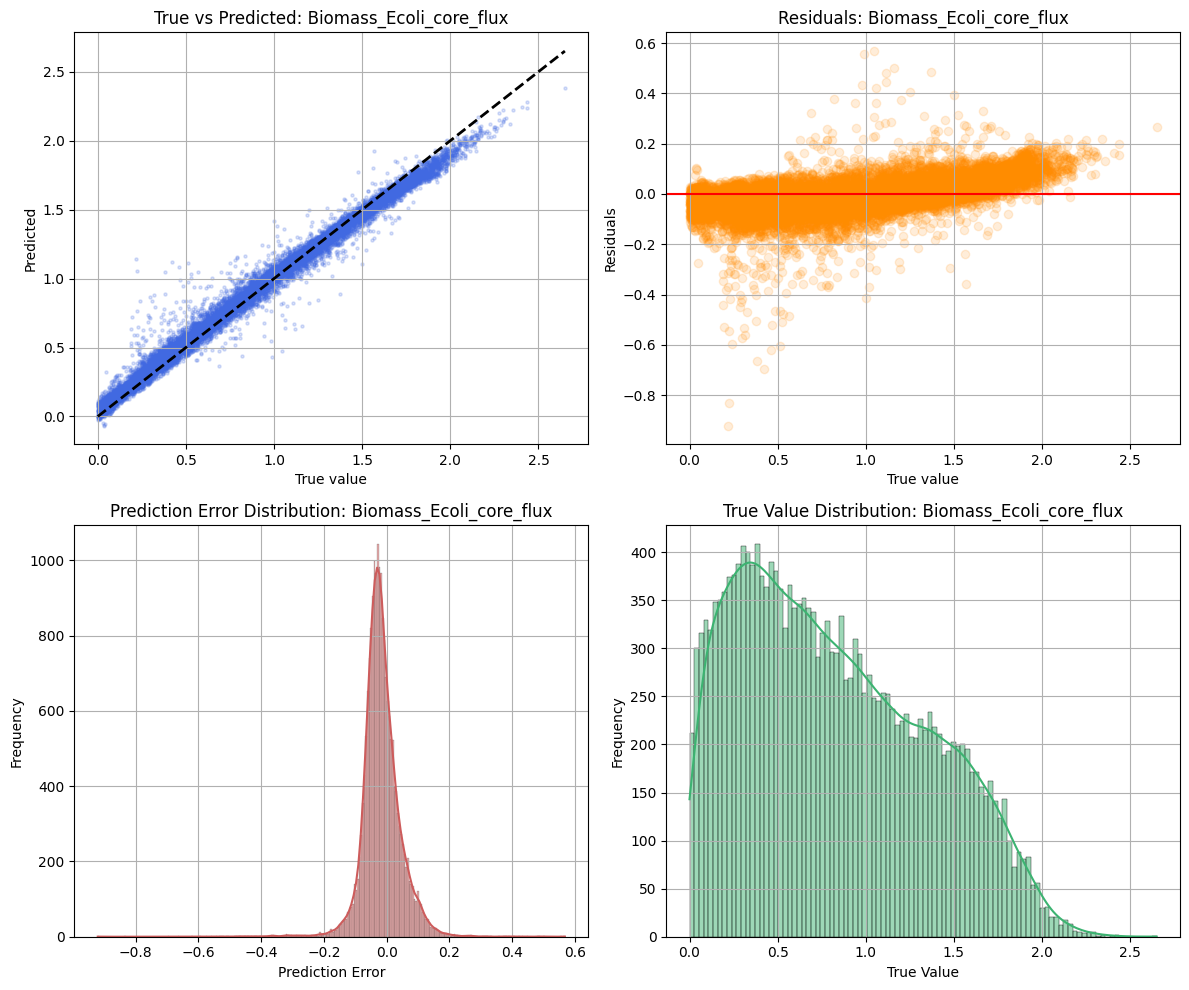

Number of parameters:
281222


In [36]:
train_losses_12842_256, test_losses_12842_256, model_12842_256 = train_model(d_model=128, n_heads=4, n_layers=2, d_ff=256)

plot_loss_curves(train_losses_12842_256, test_losses_12842_256, d_model=128, n_heads=4, n_layers=2, d_ff=256)

plot_prediction_sample(X_test, y_test, model_12842_256)

plot_flux(model_12842_256, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_12842_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.297045 | Test Loss: 0.233853
Epoch 200/1000 | Train Loss: 0.273192 | Test Loss: 0.231813
Epoch 300/1000 | Train Loss: 0.252851 | Test Loss: 0.209154
Epoch 400/1000 | Train Loss: 0.244776 | Test Loss: 0.216473
Epoch 500/1000 | Train Loss: 0.236786 | Test Loss: 0.195014
Epoch 600/1000 | Train Loss: 0.232162 | Test Loss: 0.194690
Epoch 700/1000 | Train Loss: 0.229592 | Test Loss: 0.191180
Epoch 800/1000 | Train Loss: 0.226017 | Test Loss: 0.193216
Epoch 900/1000 | Train Loss: 0.222072 | Test Loss: 0.189497
Epoch 1000/1000 | Train Loss: 0.221950 | Test Loss: 0.186805
Training Completed.
Training took 139 min 40.4 sec.


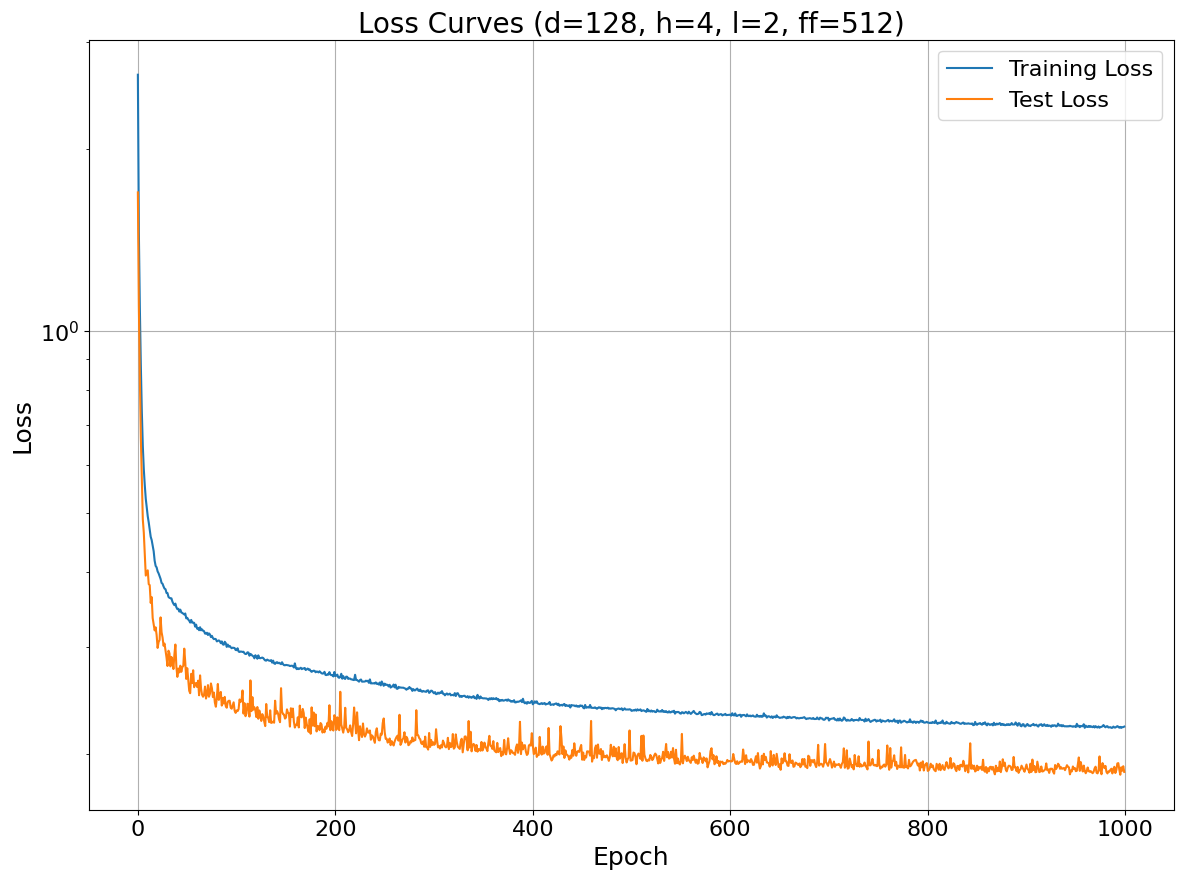

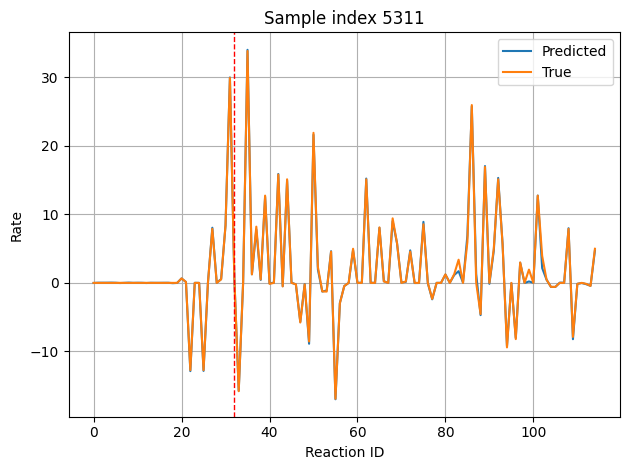

y_pred_outputs.shape: (19606, 95) min/max: -77.40772 110.076546
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.25120366 to 2.4620428


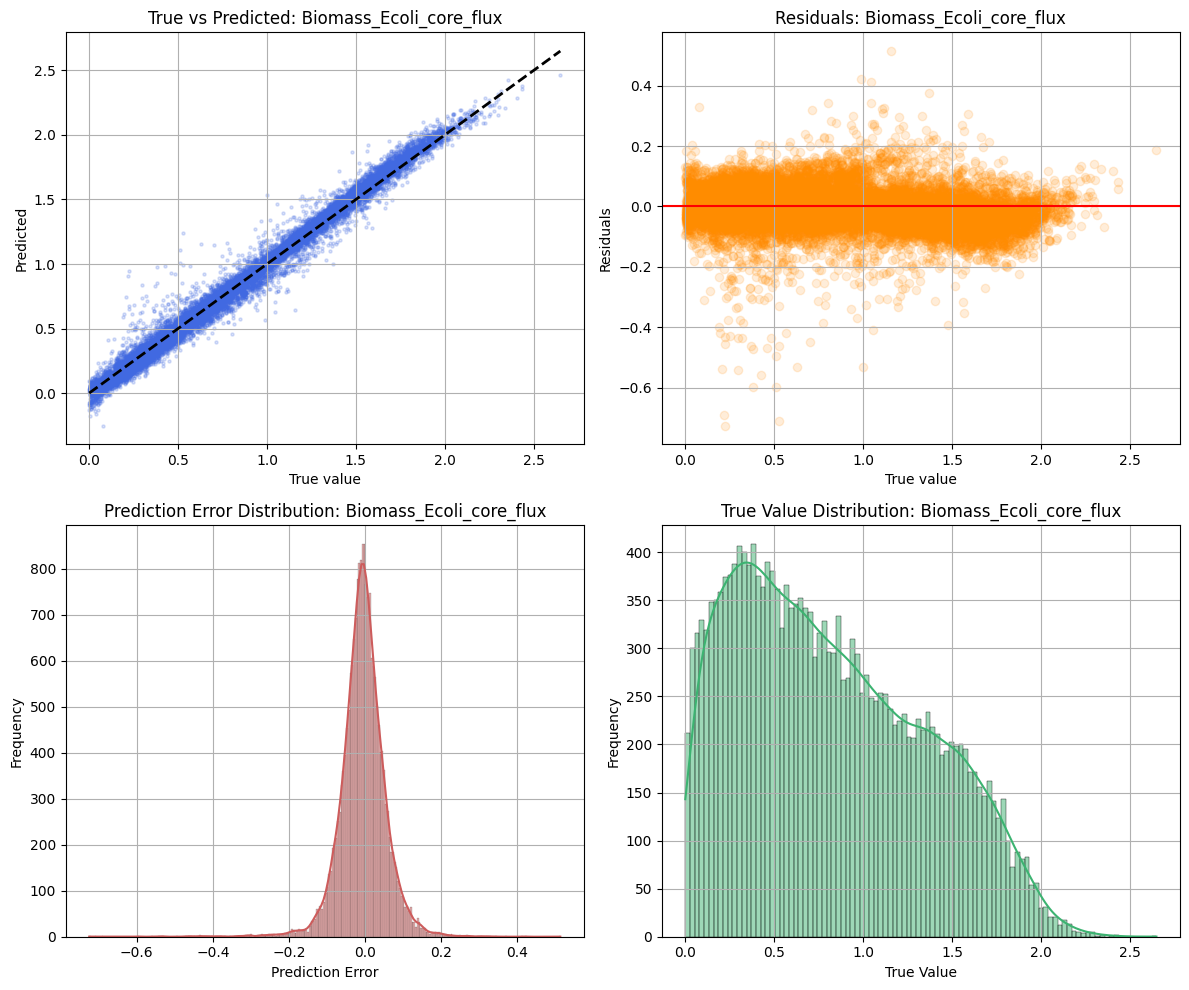

Number of parameters:
413830


In [37]:
train_losses_12842_512, test_losses_12842_512, model_12842_512 = train_model(d_model=128, n_heads=4, n_layers=2, d_ff=512)

plot_loss_curves(train_losses_12842_512, test_losses_12842_512, d_model=128, n_heads=4, n_layers=2, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12842_512)

plot_flux(model_12842_512, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_12842_512.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.222189 | Test Loss: 0.208741
Epoch 200/1000 | Train Loss: 0.197959 | Test Loss: 0.187570
Epoch 300/1000 | Train Loss: 0.184023 | Test Loss: 0.178943
Epoch 400/1000 | Train Loss: 0.175272 | Test Loss: 0.179349
Epoch 500/1000 | Train Loss: 0.166307 | Test Loss: 0.184215
Epoch 600/1000 | Train Loss: 0.157708 | Test Loss: 0.188310
Epoch 700/1000 | Train Loss: 0.148730 | Test Loss: 0.183953
Epoch 800/1000 | Train Loss: 0.140952 | Test Loss: 0.184390
Epoch 900/1000 | Train Loss: 0.133902 | Test Loss: 0.188929
Epoch 1000/1000 | Train Loss: 0.127716 | Test Loss: 0.186819
Training Completed.
Training took 207 min 3.8 sec.


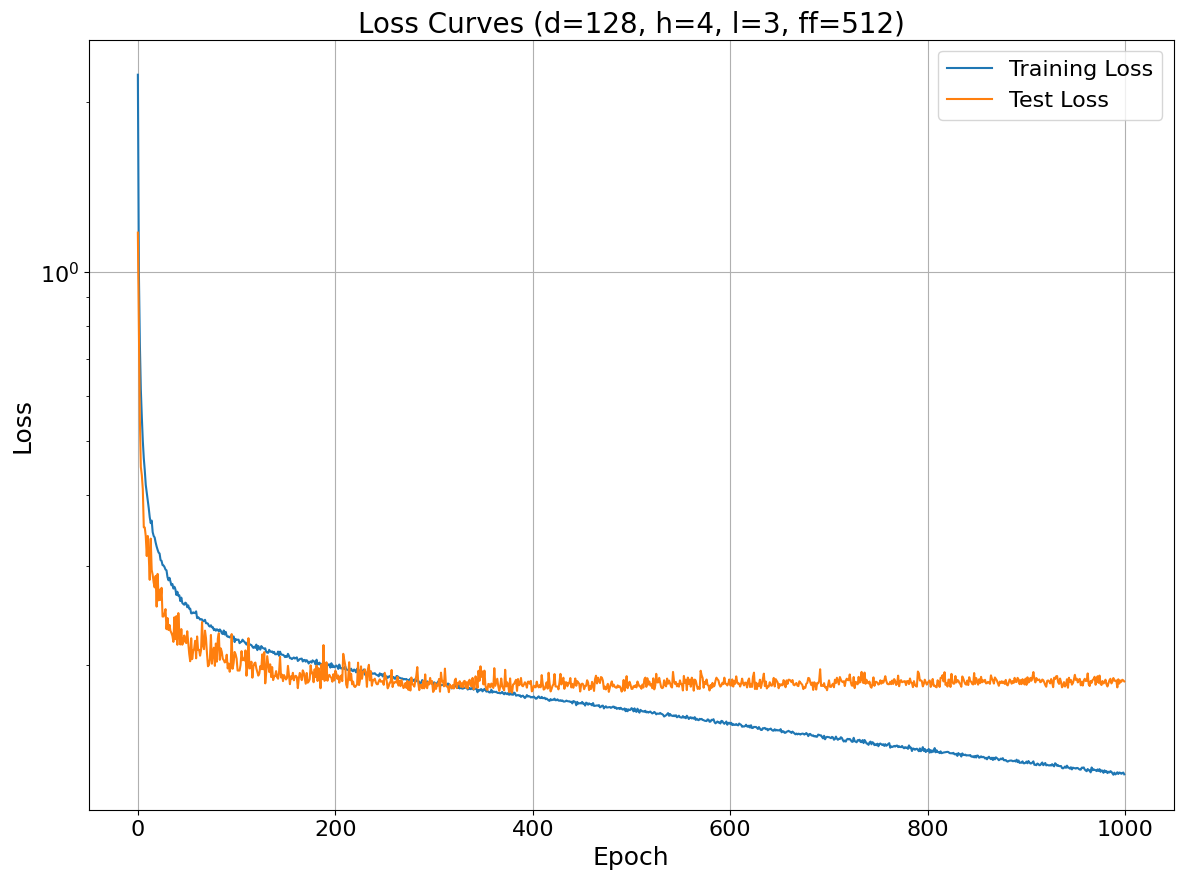

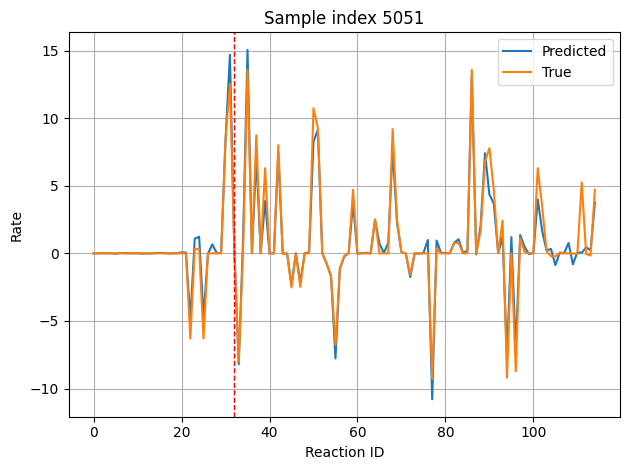

y_pred_outputs.shape: (19606, 95) min/max: -78.5711 109.579155
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.13572079 to 2.4808624


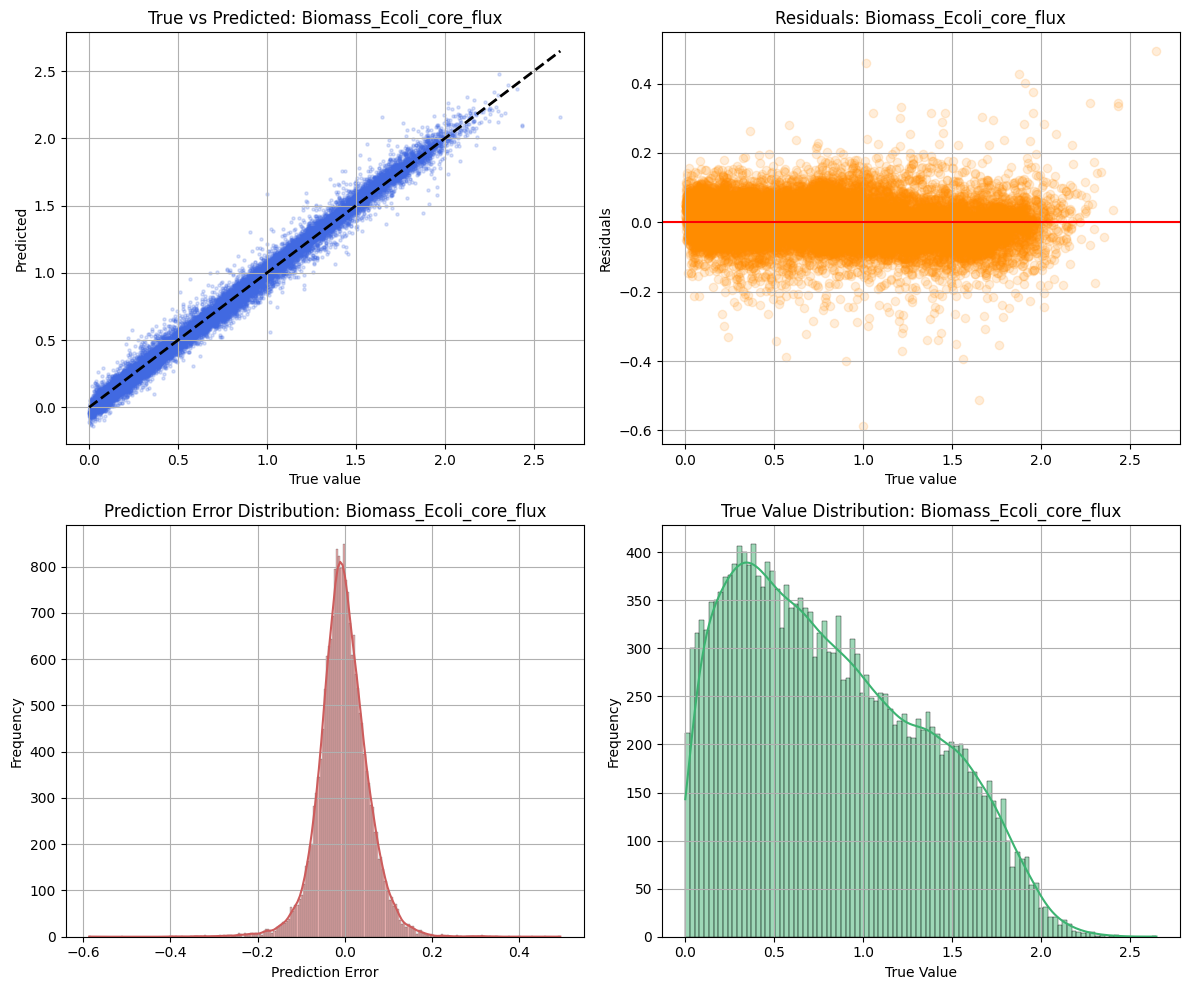

Number of parameters:
613385


In [38]:
train_losses_12843_512, test_losses_12843_512, model_12843_512 = train_model(d_model=128, n_heads=4, n_layers=3, d_ff=512)

plot_loss_curves(train_losses_12843_512, test_losses_12843_512, d_model=128, n_heads=4, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12843_512)

plot_flux(model_12843_512, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_12843_512.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.210851 | Test Loss: 0.182948
Epoch 200/1000 | Train Loss: 0.189490 | Test Loss: 0.178896
Epoch 300/1000 | Train Loss: 0.173795 | Test Loss: 0.177422
Epoch 400/1000 | Train Loss: 0.158438 | Test Loss: 0.182875
Epoch 500/1000 | Train Loss: 0.145025 | Test Loss: 0.182867
Epoch 600/1000 | Train Loss: 0.135442 | Test Loss: 0.190084
Epoch 700/1000 | Train Loss: 0.127312 | Test Loss: 0.181381
Epoch 800/1000 | Train Loss: 0.119215 | Test Loss: 0.184482
Epoch 900/1000 | Train Loss: 0.113679 | Test Loss: 0.184163
Epoch 1000/1000 | Train Loss: 0.110503 | Test Loss: 0.181209
Training Completed.
Training took 265 min 9.8 sec.


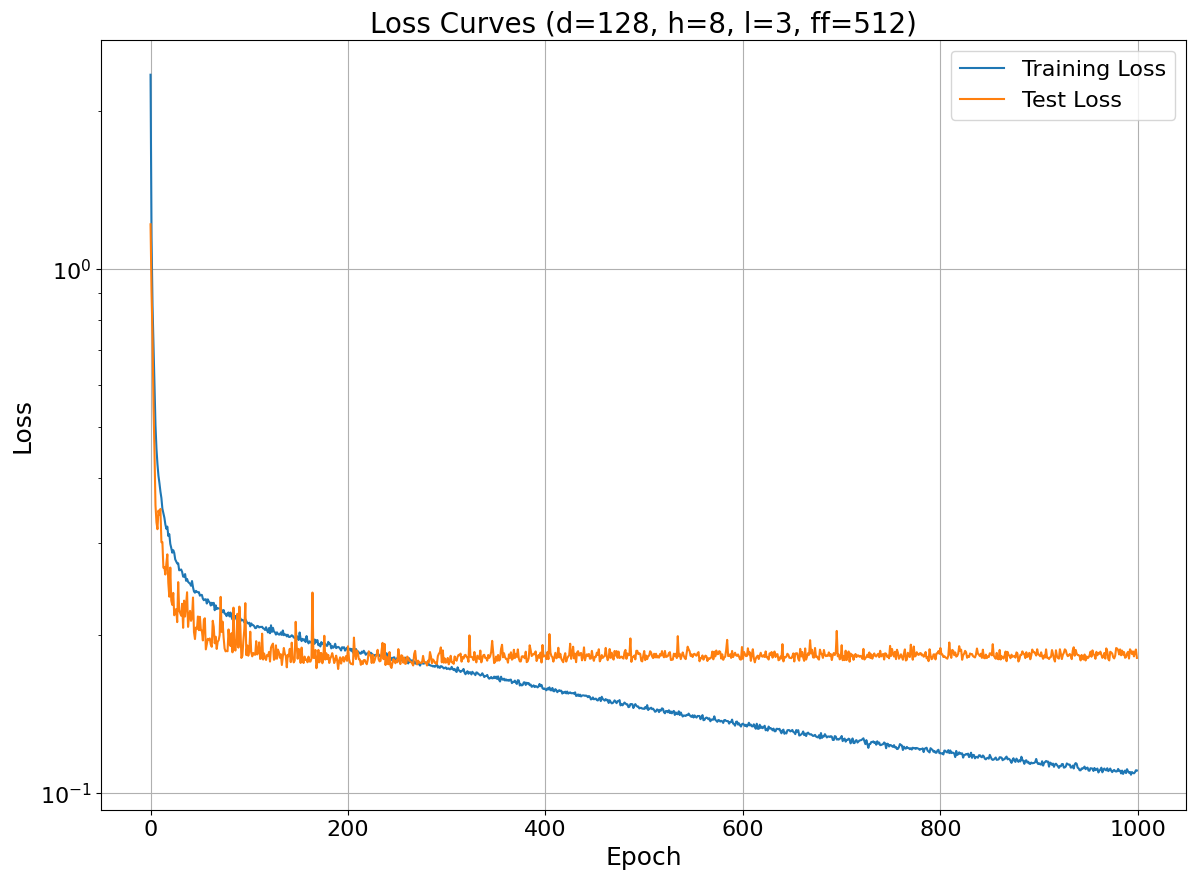

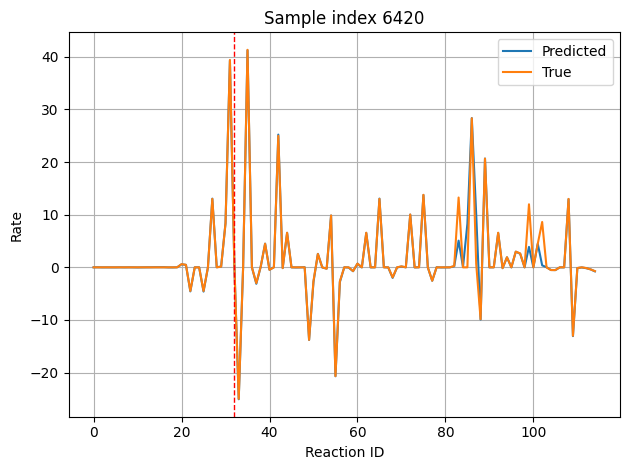

y_pred_outputs.shape: (19606, 95) min/max: -76.55103 109.82703
y_true_outputs.shape: (19606, 95) min/max: -77.737465 109.24282
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.111598015 to 2.6458035


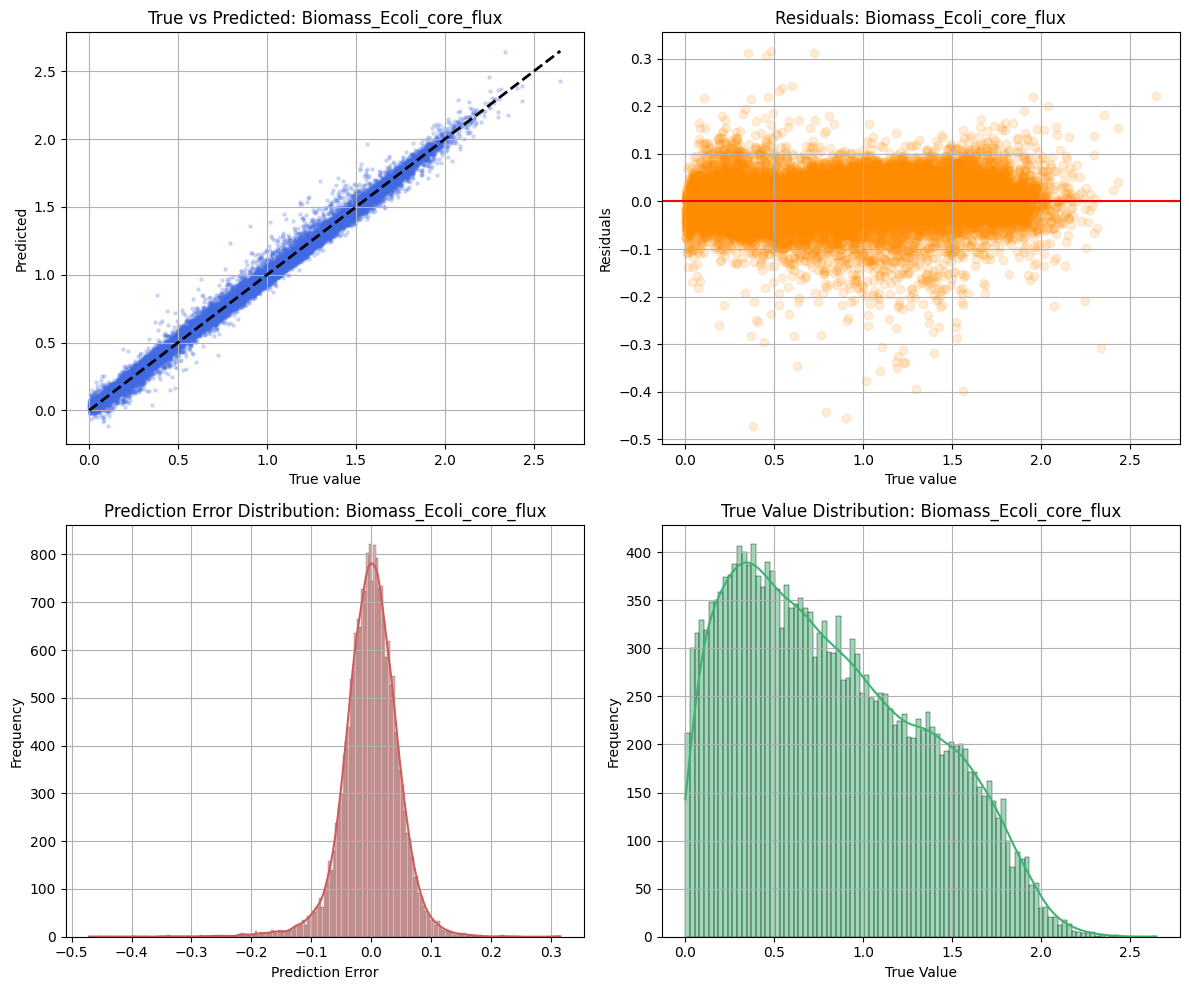

Number of parameters:
613385


In [39]:
train_losses_12883_512, test_losses_12883_512, model_12883_512 = train_model(d_model=128, n_heads=8, n_layers=3, d_ff=512)

plot_loss_curves(train_losses_12883_512, test_losses_12883_512, d_model=128, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12883_512)

plot_flux(model_12883_512, X_test, y_test, output_cols, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_12883_512.parameters() if p.requires_grad ))